train shape: (29376, 7)
origin shape: (118628, 21)
wholesale shape: (176014, 22)
weather shape: (10955, 10)

[train columns]
['시점', '품목명', '품종명', '거래단위', '등급', '평년 평균가격(원)', '평균가격(원)']

[origin columns 일부]
['시점', '공판장코드', '공판장명', '품목코드', '품목명', '품종코드', '품종명', '등급코드', '등급명', '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '중간가(원/kg)', '최저가(원/kg)', '최고가(원/kg)', '경매 건수', '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON']

[wholesale columns 일부]
['시점', '시장코드', '시장명', '품목코드', '품목명', '품종코드', '품종명', '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '고가(20%) 평균가', '중가(60%) 평균가', '저가(20%) 평균가', '중간가(원/kg)', '최저가(원/kg)', '최고가(원/kg)', '경매 건수', '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR']

[weather columns]
['지점', '지점명', '일시', '평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '평균 상대습도(%)', '합계 일조시간(hr)']

[산지공판장] 자동 탐색 결과
총반입량: 총반입량(kg)
총거래금액: 총거래금액(원)
경매건수: 경매 건수
평균가: 평균가(원/kg)
최고가: 최고가(원/kg)
최저가: 최저가(원

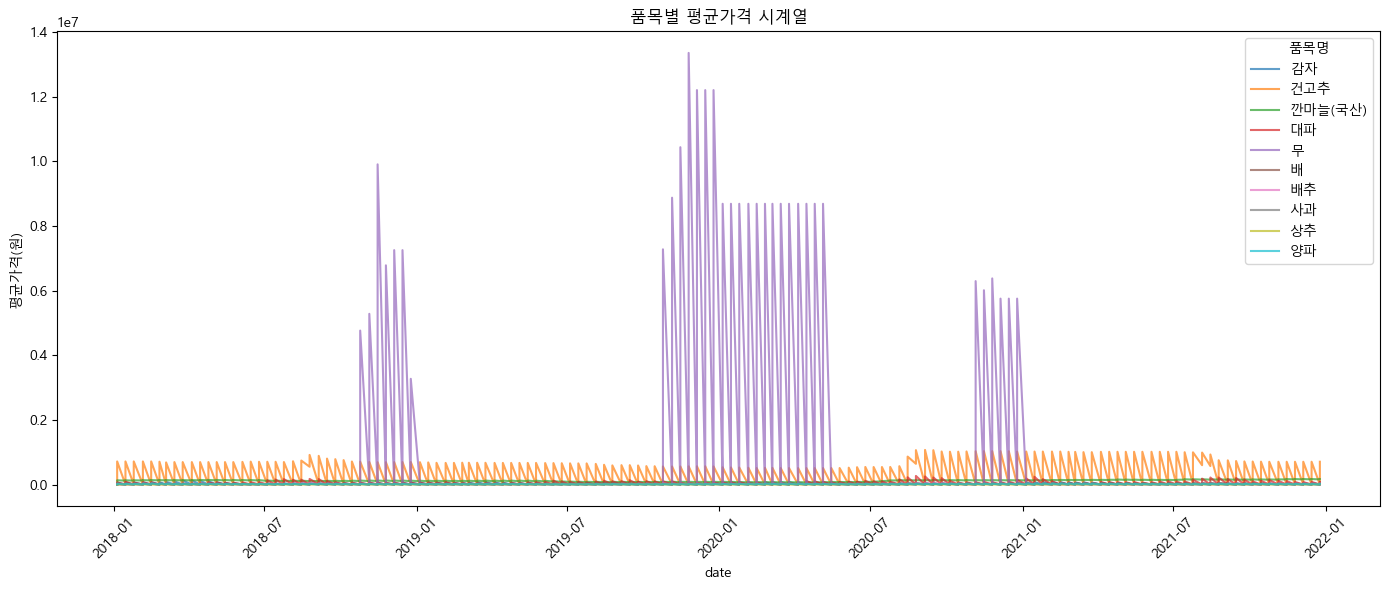

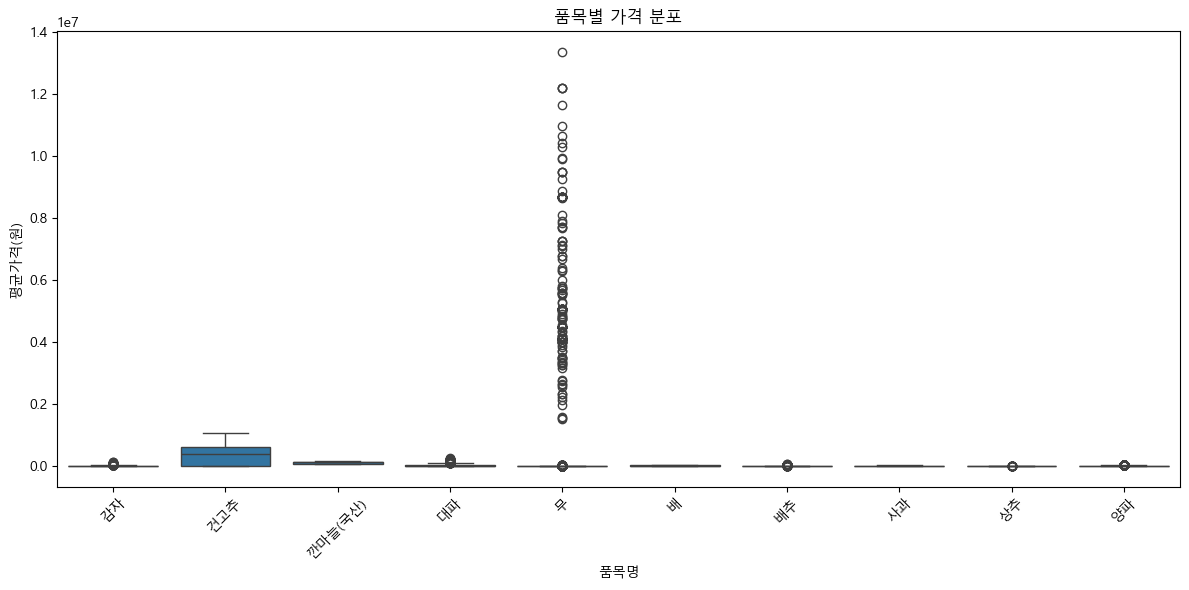

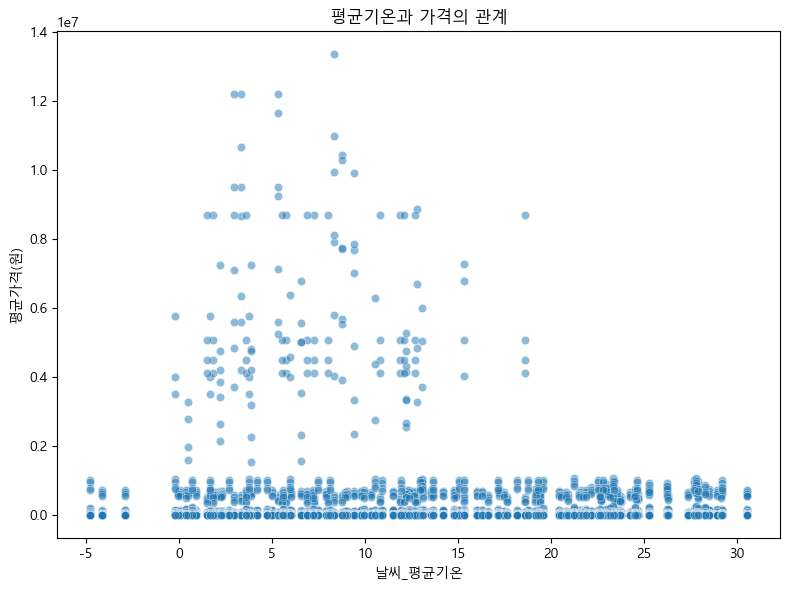

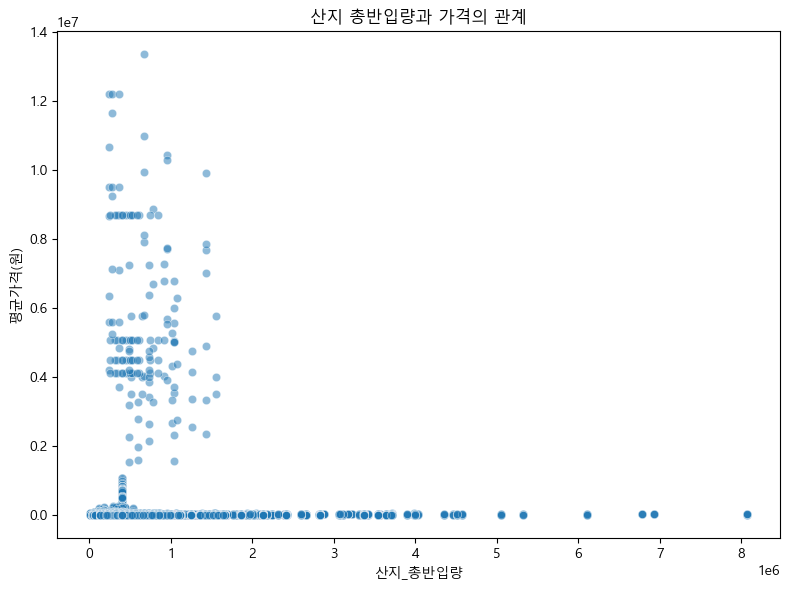

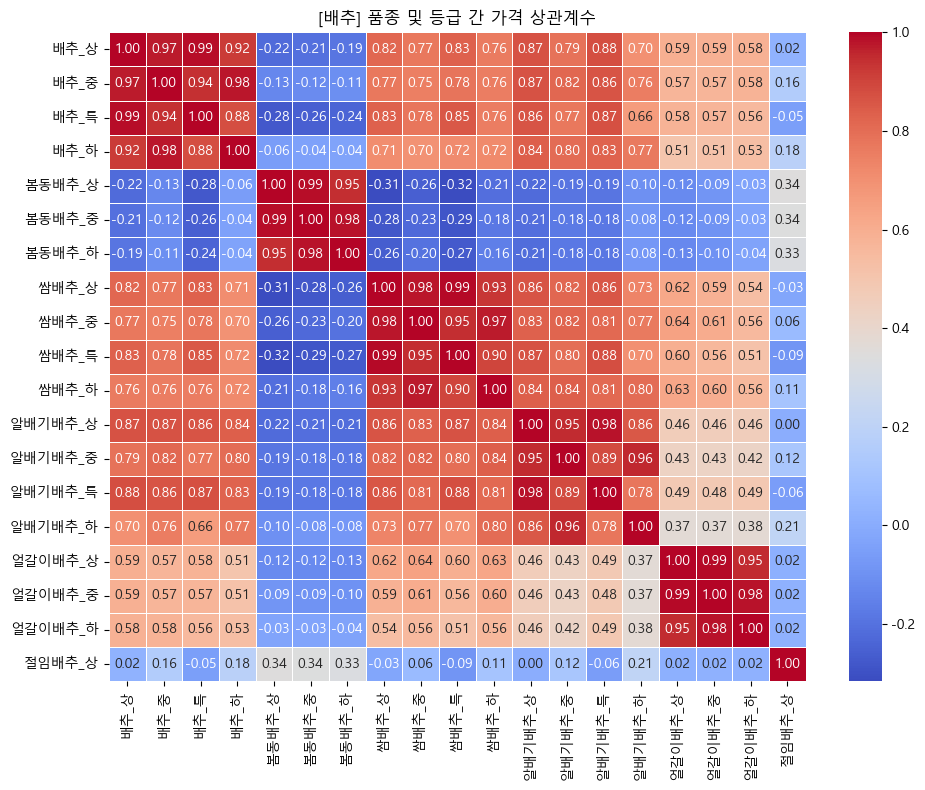

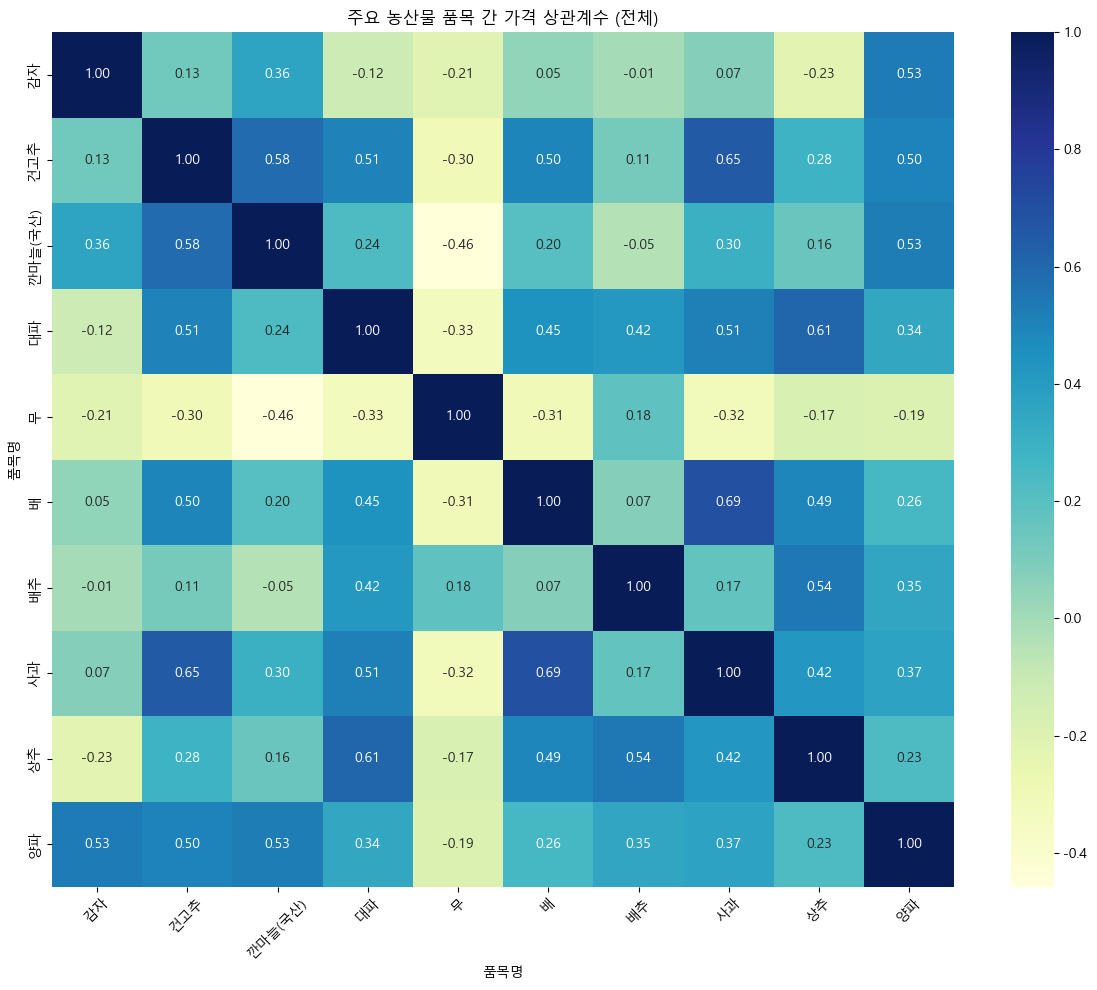

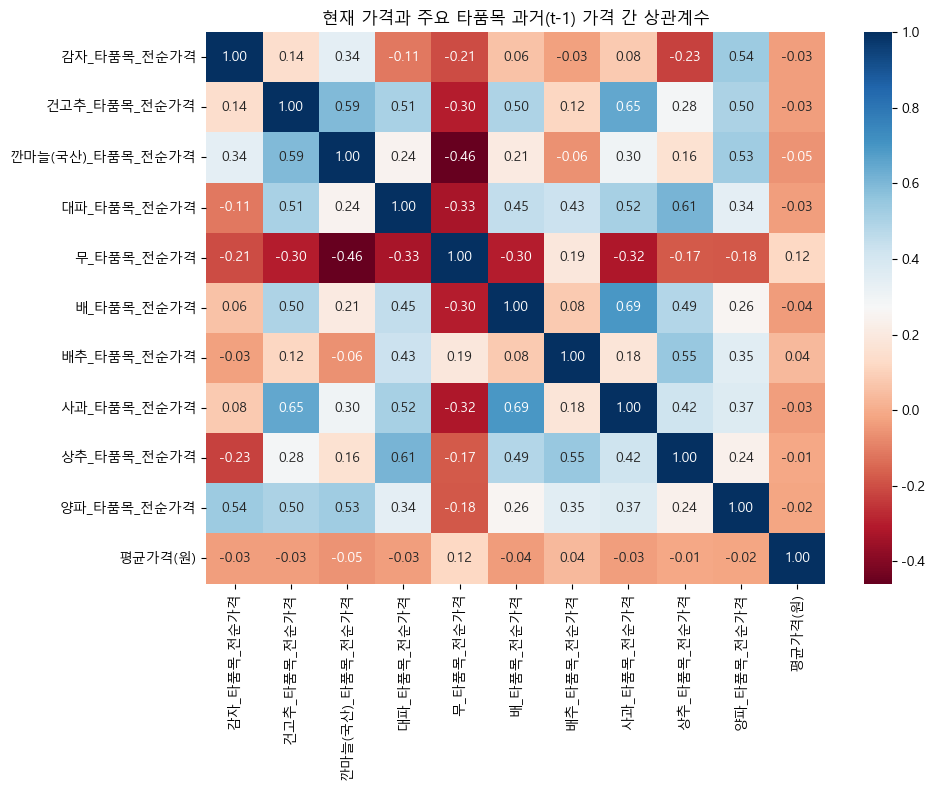


저장 완료: train_preprocessed_full.csv


In [1]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


############################################################
# 1. 파일 불러오기
# 현재 폴더 구조 기준
# ./train/train.csv
# ./train/meta/TRAIN_산지공판장_2018-2021.csv
# ./train/meta/TRAIN_전국도매_2018-2021.csv
# ./날씨.csv
############################################################
train = pd.read_csv("train.csv", encoding="cp949")
origin = pd.read_csv("TRAIN_산지공판장_2018-2021.csv", encoding="utf-8")
wholesale = pd.read_csv("TRAIN_전국도매_2018-2021.csv", encoding="utf-8")

# 날씨 파일은 보통 cp949 또는 utf-8-sig 인코딩일 수 있으므로 예외 처리
try:
    weather = pd.read_csv("날씨.csv", encoding="cp949")
except:
    try:
        weather = pd.read_csv("날씨.csv", encoding="utf-8-sig")
    except:
        weather = pd.read_csv("날씨.csv")

print("train shape:", train.shape)
print("origin shape:", origin.shape)
print("wholesale shape:", wholesale.shape)
print("weather shape:", weather.shape)


############################################################
# 2. 컬럼명 정리 함수
# - 앞뒤 공백 제거
# - 중복 공백 제거
############################################################
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df

train = clean_columns(train)
origin = clean_columns(origin)
wholesale = clean_columns(wholesale)
weather = clean_columns(weather)

print("\n[train columns]")
print(train.columns.tolist())

print("\n[origin columns 일부]")
print(origin.columns.tolist()[:20])

print("\n[wholesale columns 일부]")
print(wholesale.columns.tolist()[:20])

print("\n[weather columns]")
print(weather.columns.tolist())


############################################################
# 3. 상순/중순/하순 처리 함수
# 발표에서는 01,11,21로 볼 수도 있지만
# 분석용 대표일자는 5,15,25를 많이 사용함
# 여기서는 대표일자 5/15/25를 사용
############################################################
def soon_to_date(soon_str):
    """
    예: 201801상순 -> 2018-01-05
    """
    soon_str = str(soon_str)
    year = int(soon_str[:4])
    month = int(soon_str[4:6])
    soon = soon_str[6:]

    if soon == "상순":
        day = 5
    elif soon == "중순":
        day = 15
    else:
        day = 25

    return pd.Timestamp(year=year, month=month, day=day)

def day_to_soon(day):
    """
    일(day)을 받아 상순/중순/하순 반환
    """
    if day <= 10:
        return "상순"
    elif day <= 20:
        return "중순"
    else:
        return "하순"


############################################################
# 4. train 전처리
############################################################
train = train.copy()

# 시점 -> 날짜
train["date"] = train["시점"].apply(soon_to_date)

# year, month, day 파생
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["soon"] = train["시점"].str[-2:]

# 정렬
train = train.sort_values(["품목명", "품종명", "거래단위", "등급", "date"]).reset_index(drop=True)

# 평년 평균가격 0 -> NaN
if "평년 평균가격(원)" in train.columns:
    train["평년 평균가격(원)"] = train["평년 평균가격(원)"].replace(0, np.nan)

    # 같은 그룹 내 앞/뒤 값으로 채우기
    train["평년 평균가격(원)"] = train.groupby(
        ["품목명", "품종명", "거래단위", "등급"]
    )["평년 평균가격(원)"].transform(lambda x: x.ffill().bfill())

    # 그래도 비면 그룹 평균으로 채우기
    train["평년 평균가격(원)"] = train.groupby(
        ["품목명", "품종명", "거래단위", "등급"]
    )["평년 평균가격(원)"].transform(lambda x: x.fillna(x.mean()))

    # 마지막까지 남는 결측은 전체 중앙값
    train["평년 평균가격(원)"] = train["평년 평균가격(원)"].fillna(
        train["평년 평균가격(원)"].median()
    )

# 평년 대비 파생변수
if "평년 평균가격(원)" in train.columns:
    train["평년대비_차이"] = train["평균가격(원)"] - train["평년 평균가격(원)"]
    train["평년대비_비율"] = train["평균가격(원)"] / train["평년 평균가격(원)"]

# 로그 가격
train["log_price"] = np.log1p(train["평균가격(원)"])


############################################################
# 5. 시계열 feature 생성
# - lag
# - rolling mean
# - rolling std
# - 계절성 sin/cos
############################################################
group_cols = ["품목명", "품종명", "거래단위", "등급"]

# lag 1~8
for lag in range(1, 9):
    train[f"price_lag_{lag}"] = train.groupby(group_cols)["평균가격(원)"].shift(lag)

# 요청한 느낌 반영: lag_3, lag_5, lag_7도 따로 강조용으로 남김
train["lag_3"] = train.groupby(group_cols)["평균가격(원)"].shift(3)
train["lag_5"] = train.groupby(group_cols)["평균가격(원)"].shift(5)
train["lag_7"] = train.groupby(group_cols)["평균가격(원)"].shift(7)

# 가격 변화량
train["price_diff_1"] = train.groupby(group_cols)["평균가격(원)"].diff(1)
train["price_diff_3"] = train.groupby(group_cols)["평균가격(원)"].diff(3)

# rolling mean / std
train["rolling_mean_3"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
train["rolling_mean_5"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(5).mean()
)
train["rolling_std_3"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(3).std()
)
train["rolling_std_5"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(5).std()
)

# 모멘텀 / 평균 대비 수준
train["price_vs_ma3"] = train["평균가격(원)"] / train["rolling_mean_3"]
train["price_vs_ma5"] = train["평균가격(원)"] / train["rolling_mean_5"]

# 계절성
train["month_sin"] = np.sin(2 * np.pi * train["month"] / 12)
train["month_cos"] = np.cos(2 * np.pi * train["month"] / 12)


############################################################
# 6. 산지/도매 데이터용 공통 전처리 함수
# - 컬럼명 자동 탐색
# - 가격 정합성 보정
# - 거래 부재 판단
############################################################
def find_col(df, keywords):
    """
    df 컬럼 중 keywords를 모두 포함하는 첫 번째 컬럼 반환
    예: find_col(df, ["총반입량"]) -> "총반입량(kg)"
    """
    for col in df.columns:
        if all(k in col for k in keywords):
            return col
    return None

def preprocess_market_meta(df, data_name="meta"):
    df = df.copy()

    # 시점 -> 날짜
    if "시점" in df.columns:
        df["date"] = df["시점"].apply(soon_to_date)
        df["year"] = df["date"].dt.year
        df["month"] = df["date"].dt.month
        df["day"] = df["date"].dt.day
        df["soon"] = df["시점"].str[-2:]

    # 자주 쓰는 컬럼 자동 탐색
    qty_col = find_col(df, ["총반입량"])
    amt_col = find_col(df, ["총거래금액"])
    auction_col = find_col(df, ["경매", "건수"]) or find_col(df, ["건수"])
    
    avg_col = find_col(df, ["평균가"])
    high_col = find_col(df, ["최고가"])
    low_col = find_col(df, ["최저가"])
    mid_col = find_col(df, ["중간가"])

    # 도매 데이터에서 고가(20%) 평균가 / 중가(60%) 평균가 / 저가(20%) 평균가 같은 구조 탐색
    top20_col = find_col(df, ["고가", "20"])
    mid60_col = find_col(df, ["중가", "60"])
    low20_col = find_col(df, ["저가", "20"])

    print(f"\n[{data_name}] 자동 탐색 결과")
    print("총반입량:", qty_col)
    print("총거래금액:", amt_col)
    print("경매건수:", auction_col)
    print("평균가:", avg_col)
    print("최고가:", high_col)
    print("최저가:", low_col)
    print("중간가:", mid_col)
    print("고가20:", top20_col)
    print("중가60:", mid60_col)
    print("저가20:", low20_col)

    # 숫자형 변환
    candidate_num_cols = [
        qty_col, amt_col, auction_col, avg_col, high_col, low_col, mid_col,
        top20_col, mid60_col, low20_col
    ]
    candidate_num_cols = [c for c in candidate_num_cols if c is not None]

    for c in candidate_num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 실제 거래 부재 여부
    # 반입량, 거래금액, 경매건수가 모두 0이면 거래 부재로 판단
    df["거래부재"] = 0
    if qty_col and amt_col and auction_col:
        df["거래부재"] = (
            (df[qty_col].fillna(0) == 0) &
            (df[amt_col].fillna(0) == 0) &
            (df[auction_col].fillna(0) == 0)
        ).astype(int)

    # -----------------------------
    # 1) 최고가 >= 최저가 정합성 보정
    # -----------------------------
    # 규칙:
    # - 거래부재면 굳이 가격을 강제로 보정하지 않음
    # - 최저가가 0이고 거래부재가 아니면 그대로 둘 수 있음 (사용자 요구 반영)
    # - 최저가>0인데 최고가==0이면 이전 유효 최고가로 대체
    # - 최고가<최저가이면 둘 중 큰 값으로 최고가 보정
    # -----------------------------
    if high_col and low_col:
        # 그룹 기준: 품목명 / 품종명 / 등급 있으면 사용
        key_cols = [c for c in ["품목명", "품종명", "등급"] if c in df.columns]
        sort_cols = key_cols + ["date"] if "date" in df.columns else key_cols
        if sort_cols:
            df = df.sort_values(sort_cols).reset_index(drop=True)

        # 이전 유효 최고가
        if key_cols:
            prev_valid_high = df.groupby(key_cols)[high_col].transform(
                lambda x: x.replace(0, np.nan).ffill()
            )
        else:
            prev_valid_high = df[high_col].replace(0, np.nan).ffill()

        # 조건: 최저가 > 0인데 최고가 == 0, 그리고 거래부재 아님
        cond_replace_high = (
            (df[low_col].fillna(0) > 0) &
            (df[high_col].fillna(0) == 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_replace_high, high_col] = prev_valid_high[cond_replace_high]

        # 그래도 최고가 < 최저가면 최고가를 최저가로 보정
        cond_swap_high = (
            (df[high_col].notna()) &
            (df[low_col].notna()) &
            (df[high_col] < df[low_col]) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_swap_high, high_col] = df.loc[cond_swap_high, low_col]

    # -----------------------------
    # 2) 고가(20) >= 중가(60) >= 저가(20) 정합성 보정
    # 규칙:
    # - 거래부재면 보정하지 않음
    # - 고가=0, 중가>0, 저가>0 이면 이전 유효 고가로 대체
    # - 고가=0, 중가=0, 저가>0 이면 세 값을 저가 기준으로 맞춤
    # - 마지막으로 고/중/저 순서를 강제
    # -----------------------------
    if top20_col and mid60_col and low20_col:
        key_cols = [c for c in ["품목명", "품종명", "등급"] if c in df.columns]
        sort_cols = key_cols + ["date"] if "date" in df.columns else key_cols
        if sort_cols:
            df = df.sort_values(sort_cols).reset_index(drop=True)

        # 이전 유효 고가
        if key_cols:
            prev_valid_top = df.groupby(key_cols)[top20_col].transform(
                lambda x: x.replace(0, np.nan).ffill()
            )
        else:
            prev_valid_top = df[top20_col].replace(0, np.nan).ffill()

        # case 1: 고가 0, 중가 0, 저가>0 -> 세 값을 저가로 맞춤
        cond_all_from_low = (
            (df[top20_col].fillna(0) == 0) &
            (df[mid60_col].fillna(0) == 0) &
            (df[low20_col].fillna(0) > 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_all_from_low, top20_col] = df.loc[cond_all_from_low, low20_col]
        df.loc[cond_all_from_low, mid60_col] = df.loc[cond_all_from_low, low20_col]

        # case 2: 고가 0, 중가>0, 저가>0 -> 이전 유효 고가로 대체
        cond_top_from_prev = (
            (df[top20_col].fillna(0) == 0) &
            (df[mid60_col].fillna(0) > 0) &
            (df[low20_col].fillna(0) > 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_top_from_prev, top20_col] = prev_valid_top[cond_top_from_prev]

        # 그래도 결측/0이면 중가로 보정
        cond_top_still_bad = (
            (df[top20_col].fillna(0) == 0) &
            (df[mid60_col].fillna(0) > 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_top_still_bad, top20_col] = df.loc[cond_top_still_bad, mid60_col]

        # 순서 강제: 고가 >= 중가 >= 저가
        # 중가 < 저가이면 중가를 저가로
        cond_mid_low = (
            (df[mid60_col].notna()) &
            (df[low20_col].notna()) &
            (df[mid60_col] < df[low20_col]) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_mid_low, mid60_col] = df.loc[cond_mid_low, low20_col]

        # 고가 < 중가이면 고가를 중가로
        cond_top_mid = (
            (df[top20_col].notna()) &
            (df[mid60_col].notna()) &
            (df[top20_col] < df[mid60_col]) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_top_mid, top20_col] = df.loc[cond_top_mid, mid60_col]

    return df


############################################################
# 7. 산지공판장 / 전국도매 전처리 실행
############################################################
origin = preprocess_market_meta(origin, data_name="산지공판장")
wholesale = preprocess_market_meta(wholesale, data_name="전국도매")


############################################################
# 8. 산지공판장 / 전국도매 집계
# train과 붙이기 쉽게 시점 + 품목명 기준 집계
#
# 주의:
# 메타 데이터는 품종/등급이 train과 완전히 맞지 않을 수 있으므로
# 우선 품목명 단위 집계로 단순화
############################################################
def make_market_agg(df, prefix="산지"):
    df = df.copy()

    qty_col = find_col(df, ["총반입량"])
    amt_col = find_col(df, ["총거래금액"])
    auction_col = find_col(df, ["경매", "건수"]) or find_col(df, ["건수"])
    avg_col = find_col(df, ["평균가"])
    high_col = find_col(df, ["최고가"])
    low_col = find_col(df, ["최저가"])
    mid_col = find_col(df, ["중간가"])
    top20_col = find_col(df, ["고가", "20"])
    mid60_col = find_col(df, ["중가", "60"])
    low20_col = find_col(df, ["저가", "20"])

    agg_dict = {}

    if qty_col: agg_dict[qty_col] = "sum"
    if amt_col: agg_dict[amt_col] = "sum"
    if auction_col: agg_dict[auction_col] = "sum"
    if avg_col: agg_dict[avg_col] = "mean"
    if high_col: agg_dict[high_col] = "mean"
    if low_col: agg_dict[low_col] = "mean"
    if mid_col: agg_dict[mid_col] = "mean"
    if top20_col: agg_dict[top20_col] = "mean"
    if mid60_col: agg_dict[mid60_col] = "mean"
    if low20_col: agg_dict[low20_col] = "mean"
    if "거래부재" in df.columns: agg_dict["거래부재"] = "sum"

    out = df.groupby(["시점", "품목명"], as_index=False).agg(agg_dict)

    rename_dict = {}
    if qty_col: rename_dict[qty_col] = f"{prefix}_총반입량"
    if amt_col: rename_dict[amt_col] = f"{prefix}_총거래금액"
    if auction_col: rename_dict[auction_col] = f"{prefix}_경매건수"
    if avg_col: rename_dict[avg_col] = f"{prefix}_평균가"
    if high_col: rename_dict[high_col] = f"{prefix}_최고가"
    if low_col: rename_dict[low_col] = f"{prefix}_최저가"
    if mid_col: rename_dict[mid_col] = f"{prefix}_중간가"
    if top20_col: rename_dict[top20_col] = f"{prefix}_고가20"
    if mid60_col: rename_dict[mid60_col] = f"{prefix}_중가60"
    if low20_col: rename_dict[low20_col] = f"{prefix}_저가20"
    if "거래부재" in df.columns: rename_dict["거래부재"] = f"{prefix}_거래부재횟수"

    out = out.rename(columns=rename_dict)
    return out

origin_agg = make_market_agg(origin, prefix="산지")
wholesale_agg = make_market_agg(wholesale, prefix="도매")

print("\norigin_agg shape:", origin_agg.shape)
print("wholesale_agg shape:", wholesale_agg.shape)


############################################################
# 9. 날씨 데이터 전처리
# - 일시 -> 날짜형
# - 일 -> 순 변환
# - 순 단위 집계
############################################################
weather = weather.copy()

# 날짜 컬럼 탐색
date_col = None
for c in weather.columns:
    if "일시" in c or "date" in c.lower():
        date_col = c
        break

if date_col is None:
    raise ValueError("날씨 데이터에서 날짜 컬럼(예: 일시)을 찾지 못했습니다.")

weather[date_col] = pd.to_datetime(weather[date_col])
weather["year"] = weather[date_col].dt.year
weather["month"] = weather[date_col].dt.month
weather["day"] = weather[date_col].dt.day
weather["soon"] = weather["day"].apply(day_to_soon)
weather["시점"] = (
    weather["year"].astype(str)
    + weather["month"].astype(str).str.zfill(2)
    + weather["soon"]
)

# 자주 쓰는 날씨 컬럼 탐색
temp_avg_col = find_col(weather, ["평균기온"])
temp_min_col = find_col(weather, ["최저기온"])
temp_max_col = find_col(weather, ["최고기온"])
rain_col = find_col(weather, ["강수량"])
humid_col = find_col(weather, ["상대습도"]) or find_col(weather, ["습도"])
sun_col = find_col(weather, ["일조"])
wind_col = find_col(weather, ["풍속"])

print("\n[날씨 컬럼 자동 탐색]")
print("평균기온:", temp_avg_col)
print("최저기온:", temp_min_col)
print("최고기온:", temp_max_col)
print("강수량:", rain_col)
print("습도:", humid_col)
print("일조:", sun_col)
print("풍속:", wind_col)

weather_agg_dict = {}

if temp_avg_col: weather_agg_dict[temp_avg_col] = "mean"
if temp_min_col: weather_agg_dict[temp_min_col] = "mean"
if temp_max_col: weather_agg_dict[temp_max_col] = "mean"
if humid_col: weather_agg_dict[humid_col] = "mean"
if sun_col: weather_agg_dict[sun_col] = "mean"
if wind_col: weather_agg_dict[wind_col] = "mean"

# 강수량은 합계가 더 자연스러움
if rain_col:
    weather[rain_col] = pd.to_numeric(weather[rain_col], errors="coerce").fillna(0)
    weather_agg_dict[rain_col] = "sum"

weather_agg = weather.groupby("시점", as_index=False).agg(weather_agg_dict)

rename_weather = {}
if temp_avg_col: rename_weather[temp_avg_col] = "날씨_평균기온"
if temp_min_col: rename_weather[temp_min_col] = "날씨_최저기온"
if temp_max_col: rename_weather[temp_max_col] = "날씨_최고기온"
if rain_col: rename_weather[rain_col] = "날씨_강수량"
if humid_col: rename_weather[humid_col] = "날씨_평균습도"
if sun_col: rename_weather[sun_col] = "날씨_일조시간"
if wind_col: rename_weather[wind_col] = "날씨_평균풍속"

weather_agg = weather_agg.rename(columns=rename_weather)

print("\nweather_agg shape:", weather_agg.shape)


############################################################
# 10. train + 산지 + 도매 + 날씨 병합
############################################################
train_merged = train.merge(origin_agg, on=["시점", "품목명"], how="left")
train_merged = train_merged.merge(wholesale_agg, on=["시점", "품목명"], how="left")
train_merged = train_merged.merge(weather_agg, on="시점", how="left")


############################################################
# 11. 추가 파생변수
# - 산지/도매 가격 차이
# - 현재가격 vs 산지/도매
# - 반입량 비율
############################################################
if "도매_평균가" in train_merged.columns and "산지_평균가" in train_merged.columns:
    train_merged["도매_산지_가격차"] = train_merged["도매_평균가"] - train_merged["산지_평균가"]

if "도매_평균가" in train_merged.columns:
    train_merged["현재가격_vs_도매"] = train_merged["평균가격(원)"] - train_merged["도매_평균가"]

if "산지_평균가" in train_merged.columns:
    train_merged["현재가격_vs_산지"] = train_merged["평균가격(원)"] - train_merged["산지_평균가"]

if "도매_총반입량" in train_merged.columns and "산지_총반입량" in train_merged.columns:
    train_merged["도매_산지_반입량비"] = train_merged["도매_총반입량"] / train_merged["산지_총반입량"]

# 무한대 제거
train_merged = train_merged.replace([np.inf, -np.inf], np.nan)

############################################################
# 11-1. 품목 간 상관관계 기반 Cross-Item Lag 피처 
# - 특정 품목의 가격을 예측할 때, 상관관계가 높은 타 품목의 직전 가격을 참조
############################################################

# 1. 시점별/품목별 평균 가격 베이스 테이블 생성 (pivot)
# 이미 train_merged에 도매_평균가나 평균가격(원)이 있으므로 이를 활용
item_price_pivot = train_merged.pivot_table(
    index='시점', 
    columns='품목명', 
    values='평균가격(원)', 
    aggfunc='mean'
)

# 2. 모든 품목의 '전순(t-1)' 가격을 피처로 생성
# shift(1)을 해야 예측 시점에서 '과거 데이터'로서 사용 가능합니다.
lag_item_prices = item_price_pivot.shift(1).add_suffix('_타품목_전순가격')

# 3. 메인 데이터프레임에 결합
# '시점'을 기준으로 병합하여, 현재 행의 품목이 무엇이든 모든 품목의 과거 가격을 옆에 붙입니다.
train_merged = train_merged.merge(lag_item_prices, on='시점', how='left')

# 4. [선택] 상관관계가 특히 높은 품목들 간의 직접적인 파생변수 생성
# 예: 감자와 무의 상관관계가 높다면 그 차이나 비율을 명시적으로 계산
if '감자_타품목_전순가격' in train_merged.columns and '무_타품목_전순가격' in train_merged.columns:
    train_merged['감자_무_과거가격비율'] = train_merged['감자_타품목_전순가격'] / (train_merged['무_타품목_전순가격'] + 1e-6)
    train_merged['감자_무_과거가격차이'] = train_merged['감자_타품목_전순가격'] - train_merged['무_타품목_전순가격']

print("\n[상관관계 피처 생성 완료]")
print(f"새로 추가된 타품목 피처 수: {len(lag_item_prices.columns)}")
############################################################
# 12. 결측치 처리(간단 버전)
# - 시계열 feature나 병합 feature 결측은 그룹별 ffill/bfill
############################################################
fill_group_cols = ["품목명", "품종명", "거래단위", "등급"]

numeric_cols = train_merged.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    if col == "평균가격(원)":
        continue
    train_merged[col] = train_merged.groupby(fill_group_cols)[col].transform(lambda x: x.ffill().bfill())

# 그래도 남는 숫자형 결측은 중앙값
for col in numeric_cols:
    if col == "평균가격(원)":
        continue
    train_merged[col] = train_merged[col].fillna(train_merged[col].median())


############################################################
# 13. 간단한 검증 출력
############################################################
print("\n[최종 데이터 shape]")
print(train_merged.shape)

print("\n[품목 분포]")
print(train_merged["품목명"].value_counts())

print("\n[품종 예시]")
print(train_merged["품종명"].unique()[:20])

print("\n[등급 예시]")
print(train_merged["등급"].unique())

print("\n[거래단위 예시]")
print(train_merged["거래단위"].unique())

print("\n[결측치 상위 30개]")
print(train_merged.isnull().sum().sort_values(ascending=False).head(30))


############################################################
# 14. 기본 EDA 그래프
# 발표용 초안으로 바로 쓸 수 있는 수준
############################################################

# 한글 폰트 문제를 피하려면 환경에 맞게 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1) 품목별 가격 시계열
plt.figure(figsize=(14, 6))
sns.lineplot(data=train_merged, x="date", y="평균가격(원)", hue="품목명", estimator=None, alpha=0.7)
plt.title("품목별 평균가격 시계열")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) 품목별 가격 분포
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_merged, x="품목명", y="평균가격(원)")
plt.title("품목별 가격 분포")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) 날씨 평균기온 vs 가격
if "날씨_평균기온" in train_merged.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=train_merged, x="날씨_평균기온", y="평균가격(원)", alpha=0.5)
    plt.title("평균기온과 가격의 관계")
    plt.tight_layout()
    plt.show()

# 4) 산지 반입량 vs 가격
if "산지_총반입량" in train_merged.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=train_merged, x="산지_총반입량", y="평균가격(원)", alpha=0.5)
    plt.title("산지 총반입량과 가격의 관계")
    plt.tight_layout()
    plt.show()

############################################################
# 14-1. 상관계수 EDA (추가)
############################################################

# 1) 품목 내(Within Item) 상관계수 
# 예: 특정 품목(예: '배추')의 등급별/품종별 가격 간의 상관관계
target_item = '배추' # 확인하고 싶은 품목 하나를 지정하거나 루프를 돌릴 수 있습니다.
item_data = train_merged[train_merged['품목명'] == target_item]

# 품종과 등급을 조합한 피벗 테이블 생성
item_pivot = item_data.pivot_table(
    index='date', 
    columns=['품종명', '등급'], 
    values='평균가격(원)'
)

# 컬럼명을 보기 좋게 병합 ('품종_등급' 형태)
item_pivot.columns = [f"{col[0]}_{col[1]}" for col in item_pivot.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(item_pivot.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(f"[{target_item}] 품종 및 등급 간 가격 상관계수")
plt.tight_layout()
plt.show()


# 2) 품목 간(Cross-Item) 상관계수
# 서로 다른 품목(감자, 무, 배추 등)의 대표 가격(평균) 간의 상관관계
# 11-1단계에서 만든 item_price_pivot을 활용합니다.
plt.figure(figsize=(12, 10))
# 품목이 너무 많으면 글자가 겹치므로 주요 품목만 슬라이싱하거나 전체를 봅니다.
cross_item_corr = item_price_pivot.corr()

sns.heatmap(cross_item_corr, annot=True, cmap='YlGnBu', fmt=".2f", cbar=True)
plt.title("주요 농산물 품목 간 가격 상관계수 (전체)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) [참고] 현재 품목 가격과 '타품목_전순가격' 간의 상관관계 (Top 10만)
# 모델에 들어가는 피처들이 실제로 얼마나 유효한지 확인용
sample_cols = [c for c in train_merged.columns if '_타품목_전순가격' in c][:10] + ['평균가격(원)']
plt.figure(figsize=(10, 8))
sns.heatmap(train_merged[sample_cols].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title("현재 가격과 주요 타품목 과거(t-1) 가격 간 상관계수")
plt.tight_layout()
plt.show()


############################################################
# 15. 저장
############################################################
train_merged.to_csv("train_preprocessed_full.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: train_preprocessed_full.csv")

In [2]:
# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 평균가격이 큰 행 상위 20개 확인
train_merged.sort_values("평균가격(원)", ascending=False)[
    ["시점", "품목명", "품종명", "거래단위", "등급", "평균가격(원)"]
].head(20)

,시점,품목명,품종명,거래단위,등급,평균가격(원)
11588,201911하순,무,다발무,8톤트럭,상,1.335000e+07
11589,201912상순,무,다발무,8톤트럭,상,1.220000e+07
11591,201912하순,무,다발무,8톤트럭,상,1.220000e+07
11590,201912중순,무,다발무,8톤트럭,상,1.220000e+07
11302,201912중순,무,다발무,5톤트럭,특,1.164635e+07
11732,201911하순,무,다발무,8톤트럭,중,1.098111e+07
11301,201912상순,무,다발무,5톤트럭,특,1.065938e+07
11299,201911중순,무,다발무,5톤트럭,특,1.043343e+07
11587,201911중순,무,다발무,8톤트럭,상,1.029733e+07
11300,201911하순,무,다발무,5톤트럭,특,9.937870e+06


In [7]:
#품목별 가격 범위
train_merged.groupby("품목명")["평균가격(원)"].describe()

,count,mean,std,min,25%,50%,75%,max
품목명,,,,,,,,
감자,4752.0,11389.555808,1.763718e+04,0.0,0.0000,0.000000,19897.416670,1.289320e+05
건고추,1152.0,333839.464844,3.435171e+05,0.0,0.0000,383419.500000,628852.000000,1.070075e+06
깐마늘(국산),288.0,116155.859375,2.811972e+04,64500.0,86151.0000,122518.750000,136621.375000,1.691000e+05
대파,3024.0,26621.067438,3.682747e+04,0.0,0.0000,4023.118056,43533.151785,2.660423e+05
무,4752.0,185279.244853,1.096089e+06,0.0,0.0000,0.000000,3216.083333,1.335000e+07
배,576.0,16742.697917,1.653239e+04,0.0,0.0000,19570.500000,31583.000000,5.346300e+04
배추,3744.0,8393.955679,7.517688e+03,0.0,3343.2625,6527.819444,11527.791665,6.510838e+04
사과,720.0,9271.171528,1.098156e+04,0.0,0.0000,0.000000,19077.000000,3.533900e+04
상추,576.0,867.921875,3.840668e+02,402.0,591.0000,759.000000,1009.250000,2.403000e+03


In [8]:
#거래 단위별 가격 범위 확인
train_merged.groupby("거래단위")["평균가격(원)"].describe().sort_values("max", ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
거래단위,,,,,,,,
8톤트럭,432.0,4.903250e+05,2.019848e+06,0.000,0.000000,0.000000,0.000000,1.335000e+07
5톤트럭,576.0,1.142388e+06,2.379971e+06,0.000,0.000000,0.000000,0.000000,1.164635e+07
30 kg,1152.0,3.338395e+05,3.435171e+05,0.000,0.000000,383419.500000,628852.000000,1.070075e+06
20키로,2880.0,1.665867e+04,2.845140e+04,0.000,0.000000,9662.833333,18623.888890,2.660423e+05
10키로상자,1872.0,2.875817e+04,3.251602e+04,0.000,0.000000,22857.946430,45426.471428,2.376029e+05
20 kg,288.0,1.161559e+05,2.811972e+04,64500.000,86151.000000,122518.750000,136621.375000,1.691000e+05
20키로상자,4752.0,1.273727e+04,1.726352e+04,0.000,0.000000,5750.562500,20699.666668,1.289320e+05
8키로상자,1584.0,1.048436e+04,7.830839e+03,0.000,5540.944444,9450.027778,13947.114583,6.510838e+04
10 개,1296.0,1.259185e+04,1.421647e+04,0.000,0.000000,0.000000,24045.250000,5.346300e+04


In [9]:
train_merged.groupby("품목명")["거래단위"].nunique()

품목명
감자         3
건고추        1
깐마늘(국산)    1
대파         4
무          9
배          1
배추         6
사과         1
상추         1
양파         5
Name: 거래단위, dtype: int64

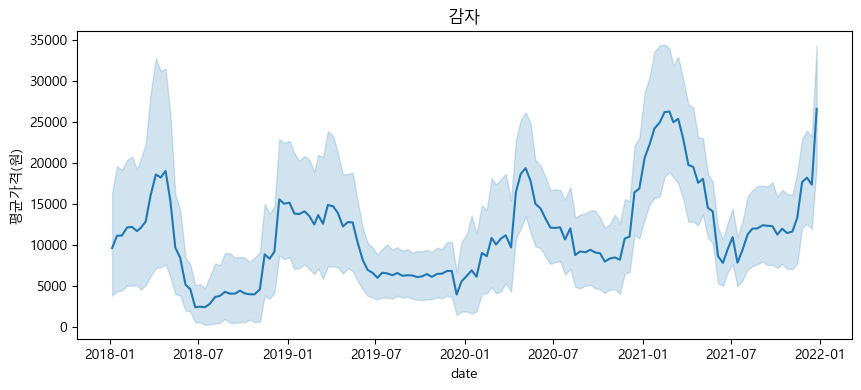

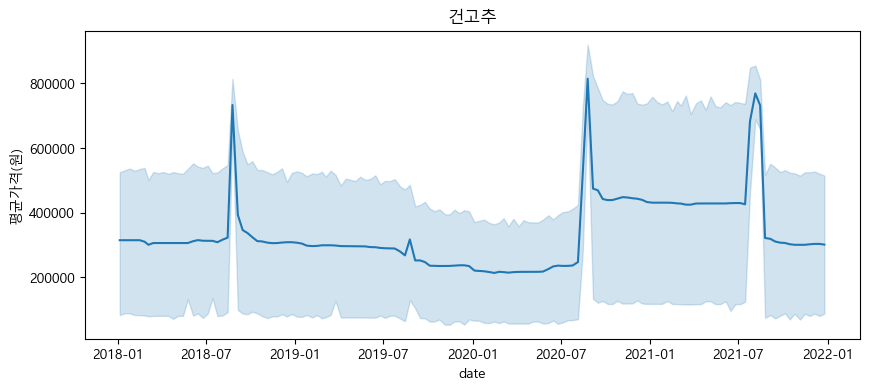

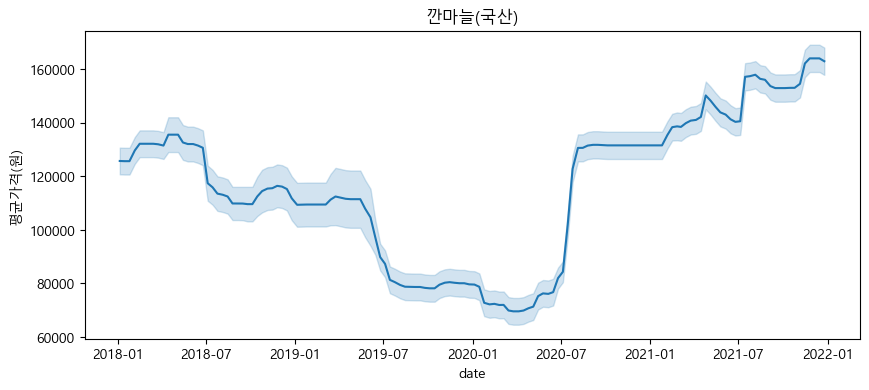

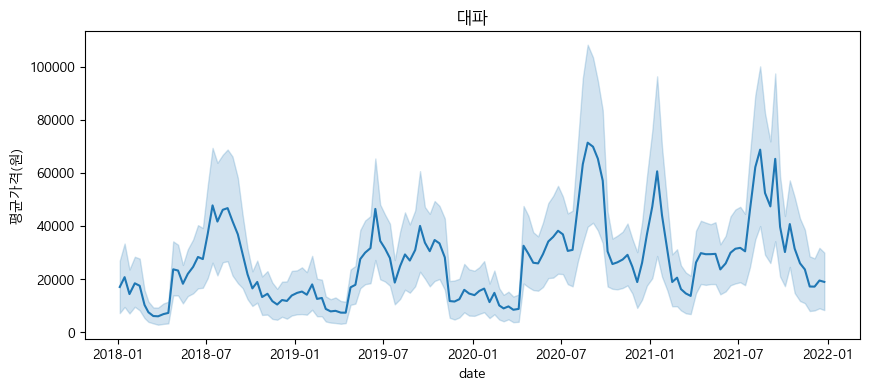

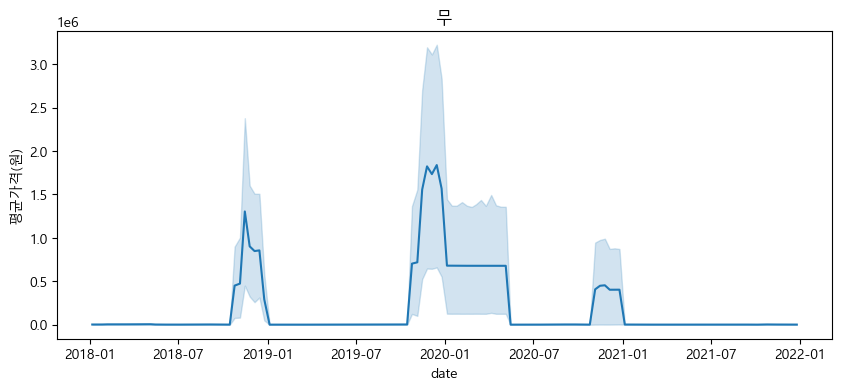

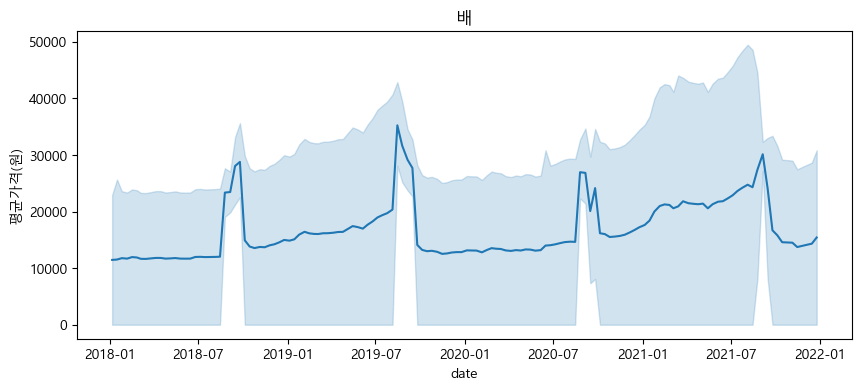

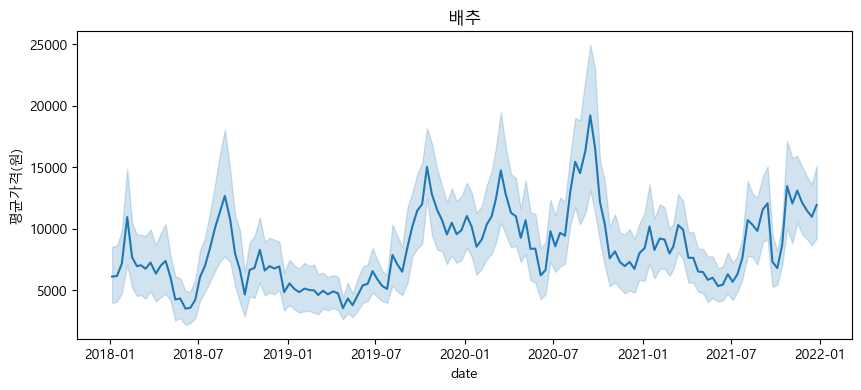

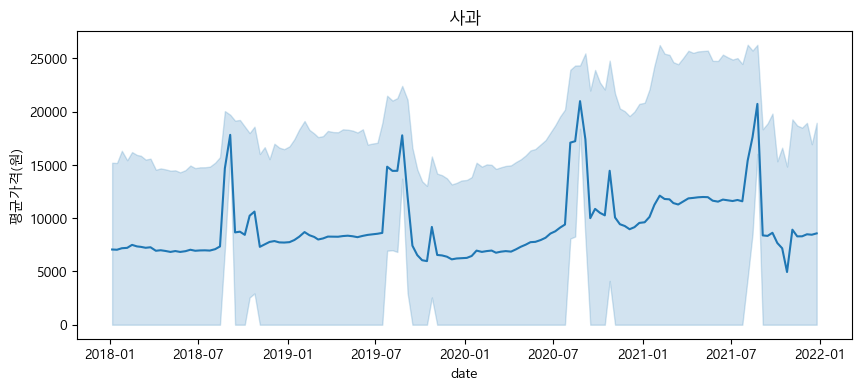

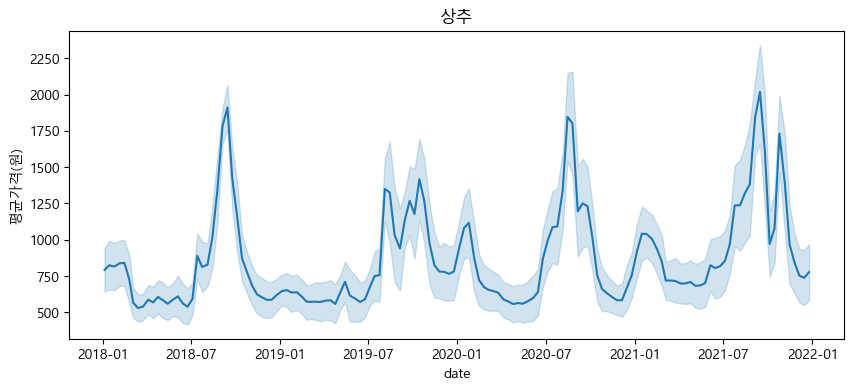

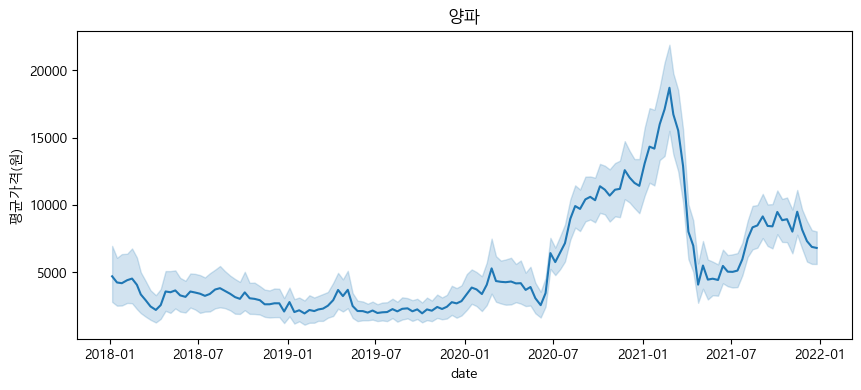

In [4]:
for item in train_merged["품목명"].unique():

    subset = train_merged[train_merged["품목명"] == item]

    plt.figure(figsize=(10,4))
    sns.lineplot(data=subset, x="date", y="평균가격(원)")
    plt.title(item)
    plt.show()

<Axes: xlabel='date', ylabel='평균가격(원)'>

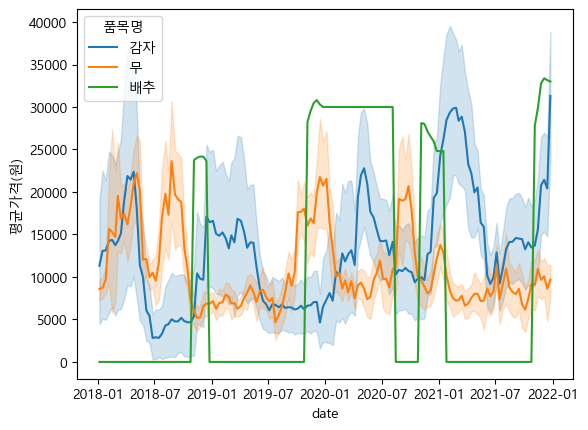

In [10]:
subset = train_merged[train_merged["거래단위"] == "20키로상자"]

sns.lineplot(data=subset, x="date", y="평균가격(원)", hue="품목명")

<Axes: xlabel='품목명', ylabel='log_price'>

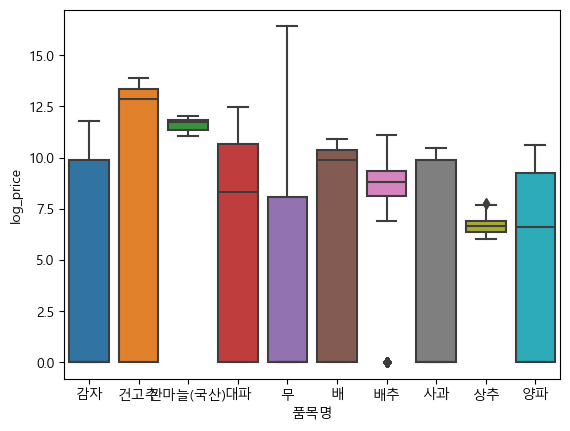

In [11]:
train_merged["log_price"] = np.log1p(train_merged["평균가격(원)"])

sns.boxplot(data=train_merged, x="품목명", y="log_price")


[품목별 내 품종 간 상관관계 시각화 시작]


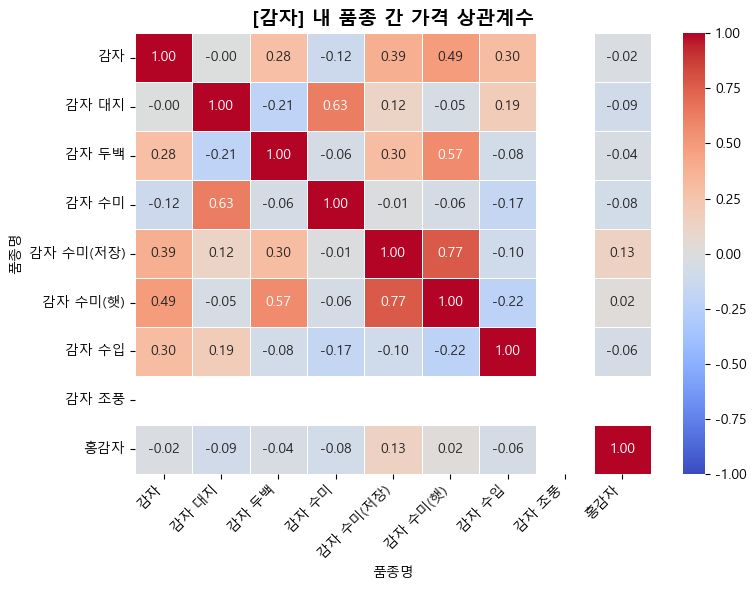

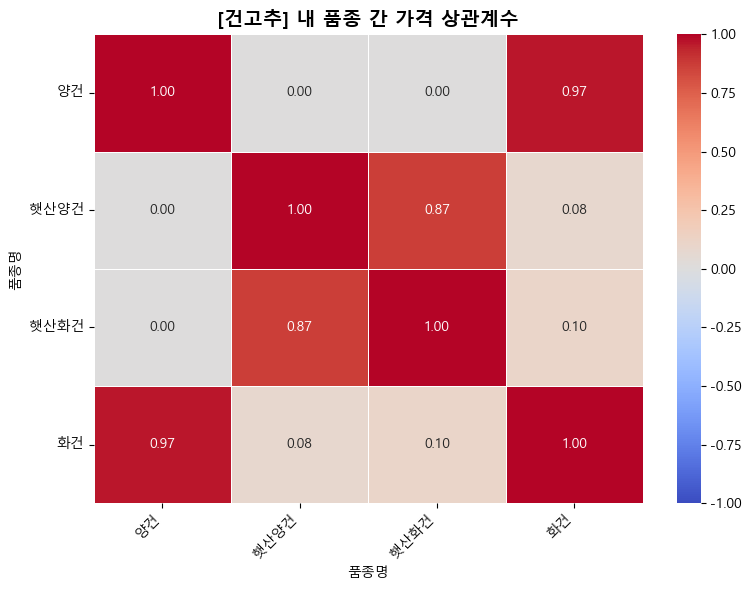

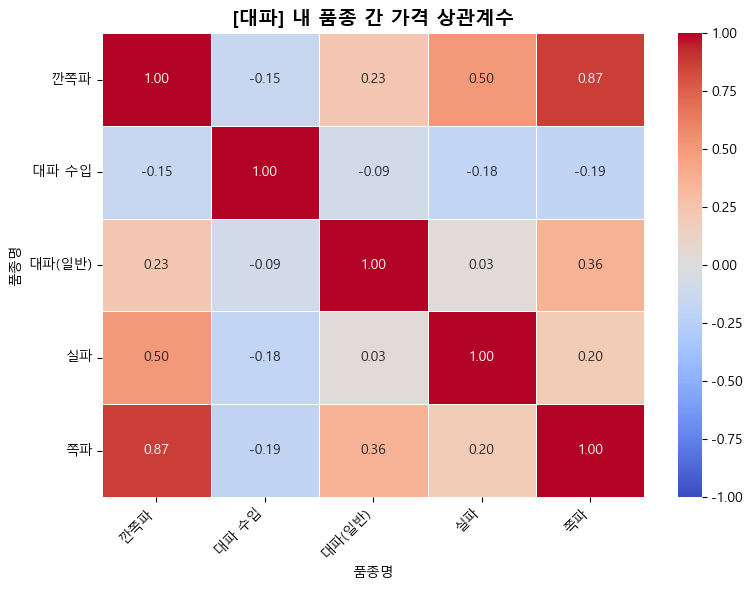

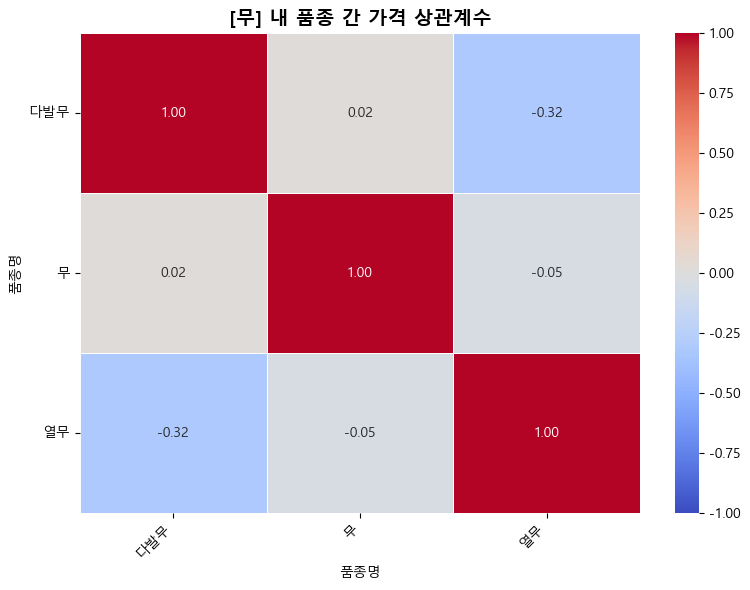

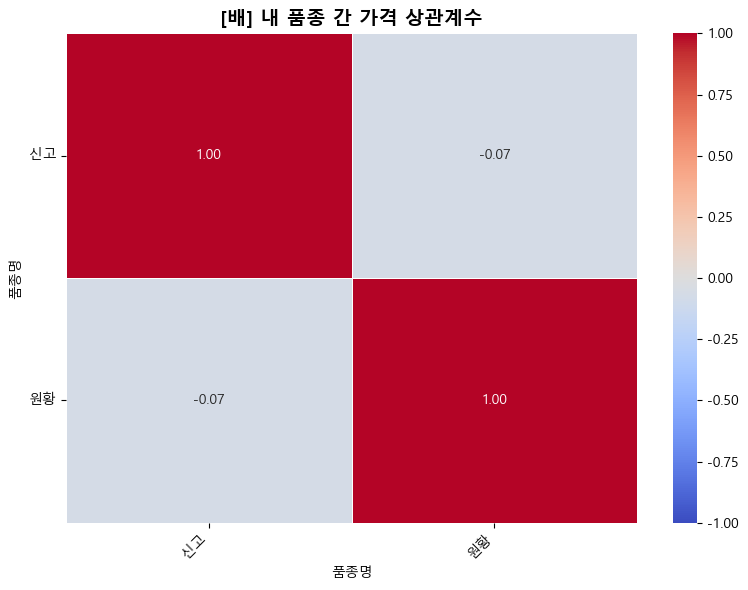

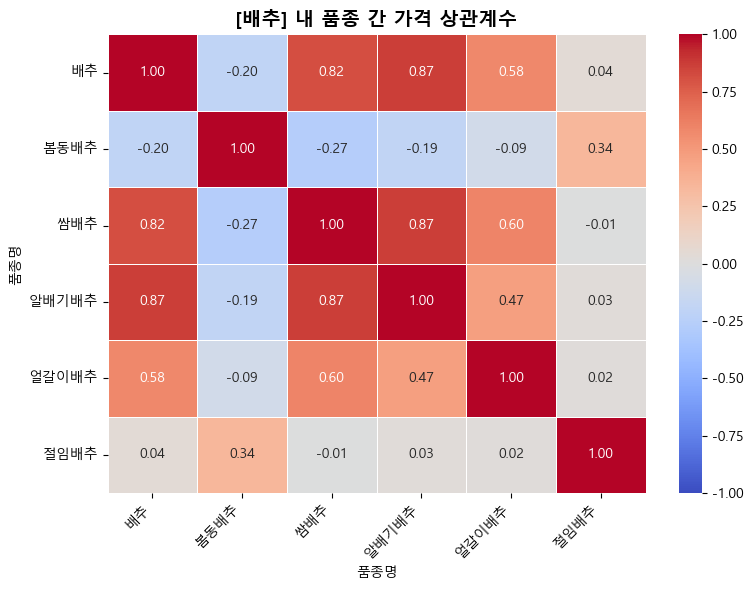

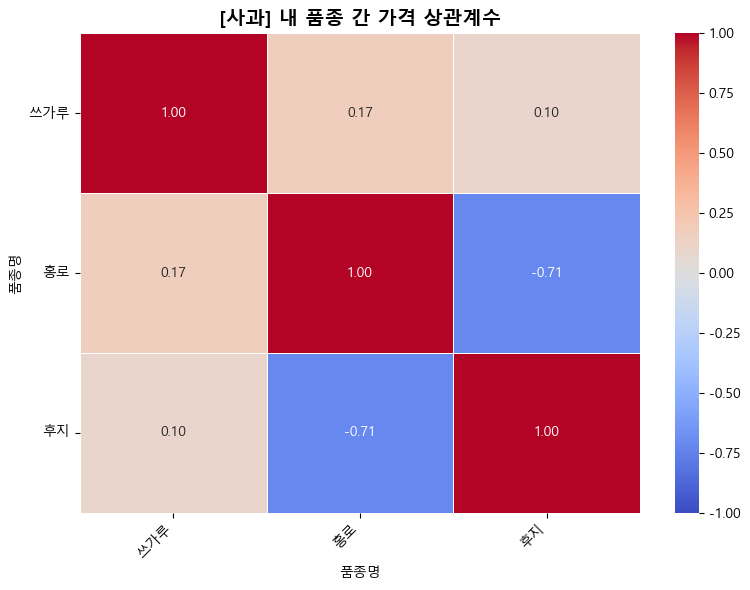

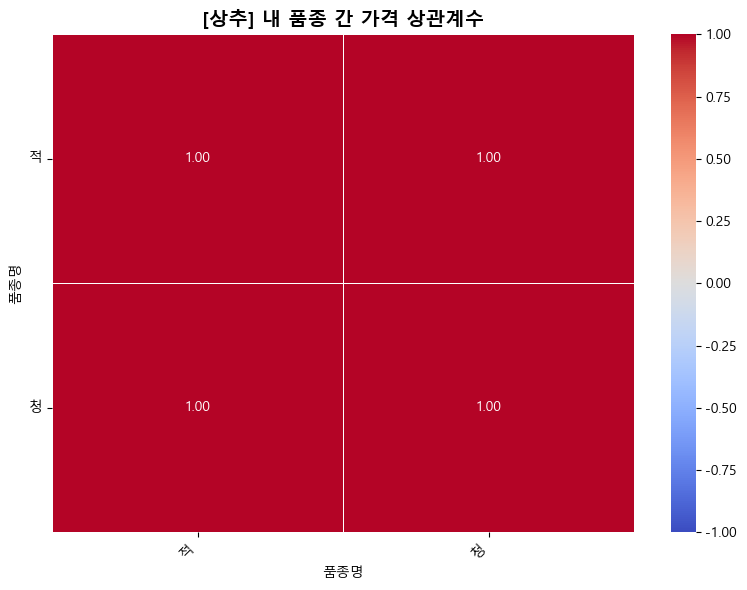

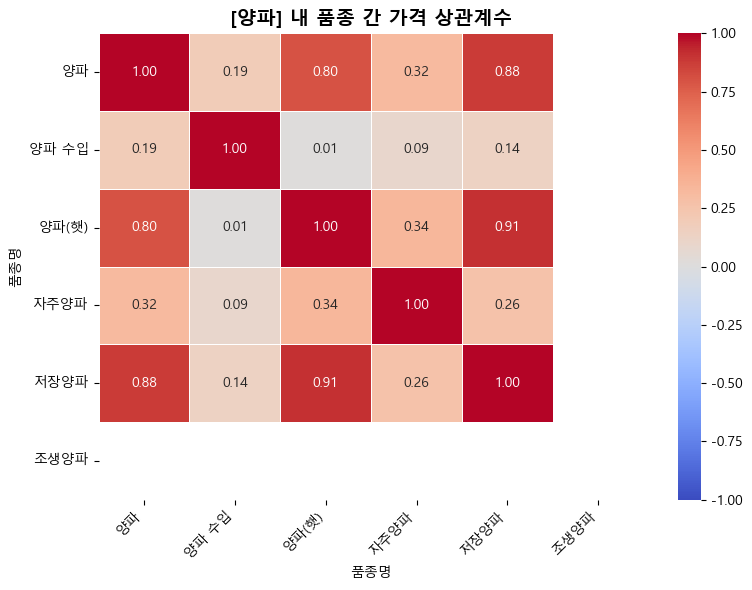

[품목별 내 품종 간 상관관계 시각화 완료]


In [12]:
############################################################
# 14-2. 모든 품목별 내 품종 간 상관계수 그래프 일괄 출력
############################################################

import matplotlib.pyplot as plt
import seaborn as sns
import platform

# --- 한글 폰트 및 마이너스 깨짐 방지 설정 ---
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False

print("\n[품목별 내 품종 간 상관관계 시각화 시작]")

# 전체 품목 리스트 추출
unique_items = train_merged['품목명'].unique()

for item in unique_items:
    # 1) 특정 품목 데이터만 필터링
    item_data = train_merged[train_merged['품목명'] == item]
    
    # 2) 해당 품목 내의 품종별 평균가격을 날짜 기준으로 피벗
    # (같은 날짜, 같은 품종에 여러 등급/단위가 있다면 평균치로 묶임)
    variety_pivot = item_data.pivot_table(
        index='date',
        columns='품종명',
        values='평균가격(원)',
        aggfunc='mean'
    )
    
    # 3) 품종이 2개 이상인 경우에만 상관계수 히트맵 출력
    if len(variety_pivot.columns) >= 2:
        plt.figure(figsize=(8, 6))
        variety_corr = variety_pivot.corr()
        
        # vmin=-1, vmax=1을 설정하여 색상 기준을 통일하면 비교하기 좋습니다.
        sns.heatmap(variety_corr, annot=True, cmap='coolwarm', fmt=".2f", 
                    linewidths=0.5, vmin=-1, vmax=1, cbar=True)
        plt.title(f"[{item}] 내 품종 간 가격 상관계수", fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        # 품종이 1개뿐인 품목은 스킵 (안내 메시지만 출력)
        # print(f"[{item}] 품목은 하위 품종이 1개뿐이어서 상관계수 그래프를 생략합니다.")
        pass

print("[품목별 내 품종 간 상관관계 시각화 완료]")

In [3]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 24.1 MB/s  0:00:00


In [6]:
#베이스라인 코드 돌려보기
############################################################
# 0. 라이브러리
############################################################
import os
import glob
import warnings
import re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

# lightgbm이 설치 안 되어 있으면 아래 주석 해제 후 1회 실행
# !pip install lightgbm
from lightgbm import LGBMRegressor


############################################################
# 1. 설정
############################################################
TRAIN_PATH = r"C:\Users\조영우\Desktop\DScover\train\train.csv"
TEST_GLOB = r"C:\Users\조영우\Desktop\DScover\test\TEST_*.csv"
SUBMISSION_PATH = r"C:\Users\조영우\Desktop\DScover\train\sample_submission.csv"
OUTPUT_PATH = r"C:\Users\조영우\Desktop\DScover\baseline_xgb_lgb_submission.csv"

# 대회 설명의 정확한 target map
TARGET_MAP = {
    "건고추": {"품종명": "화건", "거래단위": "30 kg", "등급": "상품"},
    "사과": {"품종명": ["홍로", "후지"], "거래단위": "10 개", "등급": "상품"},  # 사과는 두 품종 평균
    "감자": {"품종명": "감자 수미", "거래단위": "20키로상자", "등급": "상"},
    "배": {"품종명": "신고", "거래단위": "10 개", "등급": "상품"},
    "깐마늘(국산)": {"품종명": "깐마늘(국산)", "거래단위": "20 kg", "등급": "상품"},
    "무": {"품종명": "무", "거래단위": "20키로상자", "등급": "상"},
    "상추": {"품종명": "청", "거래단위": "100 g", "등급": "상품"},
    "배추": {"품종명": "배추", "거래단위": "10키로망대", "등급": "상"},
    "양파": {"품종명": "양파", "거래단위": "1키로", "등급": "상"},
    "대파": {"품종명": "대파(일반)", "거래단위": "1키로단", "등급": "상"},
}


############################################################
# 2. 유틸 함수
############################################################
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df

import re
import pandas as pd
import numpy as np

def soon_to_date(x):
    """
    train:
      201801상순, 201801중순, 201801하순
    test:
      T-8, T-7, ..., T-1, T
      또는 T-8순, T순 같은 형태도 같이 허용
    """
    x = str(x).strip()

    # 1. train absolute 형식
    if re.match(r"^\d{6}(상순|중순|하순)$", x):
        year = int(x[:4])
        month = int(x[4:6])
        soon = x[6:]

        if soon == "상순":
            day = 1
        elif soon == "중순":
            day = 11
        else:
            day = 21

        return pd.Timestamp(year=year, month=month, day=day)

    # 2. test relative 형식: T, T-8, T+1, T-8순, T순 ...
    if re.match(r"^T([+-]\d+)?(순)?$", x):
        base = pd.Timestamp(2000, 1, 21)  # T의 기준 가상 날짜

        if x in ["T", "T순"]:
            offset = 0
        else:
            offset = int(re.findall(r"([+-]\d+)", x)[0])

        return base + pd.Timedelta(days=10 * offset)

    raise ValueError(f"알 수 없는 시점 형식: {x}")

def date_to_soon(dt):
    year = dt.year
    month = dt.month
    day = dt.day

    if day <= 10:
        soon = "상순"
    elif day <= 20:
        soon = "중순"
    else:
        soon = "하순"

    return f"{year}{str(month).zfill(2)}{soon}"

def next_soon_str(soon_str, step=1):
    """
    train absolute 형식 / test relative 형식 둘 다 처리
    예:
      202112하순 -> 202201상순
      T-1 -> T
      T -> T+1
    """
    x = str(soon_str).strip()

    # 1. test relative 형식
    if re.match(r"^T([+-]\d+)?(순)?$", x):
        if x in ["T", "T순"]:
            cur = 0
        else:
            cur = int(re.findall(r"([+-]\d+)", x)[0])

        new_val = cur + step

        if new_val == 0:
            return "T"
        elif new_val > 0:
            return f"T+{new_val}"
        else:
            return f"T{new_val}"

    # 2. train absolute 형식
    dt = soon_to_date(x)

    for _ in range(step):
        if dt.day == 1:
            dt = pd.Timestamp(dt.year, dt.month, 11)
        elif dt.day == 11:
            dt = pd.Timestamp(dt.year, dt.month, 21)
        else:
            if dt.month == 12:
                dt = pd.Timestamp(dt.year + 1, 1, 1)
            else:
                dt = pd.Timestamp(dt.year, dt.month + 1, 1)

    return date_to_soon(dt)

def make_time_features(df):
    df = df.copy()

    df["date"] = df["시점"].apply(soon_to_date)
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day

    def extract_soon_label(x):
        x = str(x).strip()

        if "상순" in x:
            return "상순"
        elif "중순" in x:
            return "중순"
        elif "하순" in x:
            return "하순"
        elif re.match(r"^T([+-]\d+)?(순)?$", x):
            # test 상대시점은 순 대신 relative로 표시
            return "relative"
        else:
            return "unknown"

    df["soon"] = df["시점"].apply(extract_soon_label)

    def extract_t_index(x):
        x = str(x).strip()

        if x in ["T", "T순"]:
            return 0

        if re.match(r"^T([+-]\d+)?(순)?$", x):
            vals = re.findall(r"([+-]\d+)", x)
            if len(vals) > 0:
                return int(vals[0])
            return 0

        return np.nan

    df["t_index"] = df["시점"].apply(extract_t_index)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

def select_target_rows(df, target_map):
    """
    대회 예측 대상 10개 조합만 필터링
    사과는 홍로/후지 둘 다 선택
    """
    out = []

    for item, cond in target_map.items():
        if item == "사과":
            temp = df[
                (df["품목명"] == item) &
                (df["품종명"].isin(cond["품종명"])) &
                (df["거래단위"] == cond["거래단위"]) &
                (df["등급"] == cond["등급"])
            ].copy()
        else:
            temp = df[
                (df["품목명"] == item) &
                (df["품종명"] == cond["품종명"]) &
                (df["거래단위"] == cond["거래단위"]) &
                (df["등급"] == cond["등급"])
            ].copy()

        out.append(temp)

    out = pd.concat(out, axis=0).reset_index(drop=True)
    return out

def fill_normal_price(df, group_cols):
    """
    평년 평균가격 0 처리
    """
    df = df.copy()

    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df.groupby(group_cols)["평년 평균가격(원)"].transform(
            lambda x: x.ffill().bfill()
        )
        df["평년 평균가격(원)"] = df.groupby(group_cols)["평년 평균가격(원)"].transform(
            lambda x: x.fillna(x.mean())
        )
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
            df["평년 평균가격(원)"].median()
        )

    return df
    

def make_series_features(df, group_cols):
    """
    lag, rolling, diff 생성
    주의: rolling은 현재값 누수 방지를 위해 shift(1) 후 계산
    """
    df = df.copy()
    df = df.sort_values(group_cols + ["date"]).reset_index(drop=True)

    # lag 1~8
    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df.groupby(group_cols)["평균가격(원)"].shift(lag)

    # 발표용 강조 lag
    df["lag_3"] = df.groupby(group_cols)["평균가격(원)"].shift(3)
    df["lag_5"] = df.groupby(group_cols)["평균가격(원)"].shift(5)
    df["lag_7"] = df.groupby(group_cols)["평균가격(원)"].shift(7)

    # rolling
    df["rolling_mean_3"] = df.groupby(group_cols)["평균가격(원)"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    df["rolling_mean_5"] = df.groupby(group_cols)["평균가격(원)"].transform(
        lambda x: x.shift(1).rolling(5).mean()
    )
    df["rolling_std_5"] = df.groupby(group_cols)["평균가격(원)"].transform(
        lambda x: x.shift(1).rolling(5).std()
    )

    # 변화량
    df["diff_1"] = df.groupby(group_cols)["평균가격(원)"].diff(1)
    df["diff_3"] = df.groupby(group_cols)["평균가격(원)"].diff(3)

    return df

def add_target_next(df, group_cols):
    """
    1-step ahead target 생성
    """
    df = df.copy()
    df["target_next"] = df.groupby(group_cols)["평균가격(원)"].shift(-1)
    return df

############################################################
# [새로 추가] 상관관계 기반 파생변수 생성 함수
############################################################
def make_cross_item_features(df):
    """
    전체 품목의 과거 가격을 바탕으로 상관관계가 높은 품목 간의 파생변수 생성
    (주의: df에는 반드시 모든 품목의 데이터가 들어있어야 의미가 있음)
    """
    df = df.copy()
    
    # 1. 시점별/품목별 평균 가격 베이스 테이블 생성 (pivot)
    # 현재 df에 있는 품목들의 '평균가격(원)'을 시점별로 나열
    item_price_pivot = df.pivot_table(
        index='시점', 
        columns='품목명', 
        values='평균가격(원)', 
        aggfunc='mean'
    )
    
    # 2. 모든 품목의 '전순(t-1)' 가격을 피처로 생성
    lag_item_prices = item_price_pivot.shift(1).add_suffix('_타품목_전순가격')
    
    # 3. 메인 데이터프레임에 결합
    df = df.merge(lag_item_prices, on='시점', how='left')
    
    # 4. 미리 지정해 둔 '단짝 품목(상관계수 0.6 이상)' 쌍
    # (어제 EDA를 통해 발견한 강한 상관관계 쌍을 직접 하드코딩해 주면 제일 안전하고 빨라)
    # 예시: 감자와 무, 배추와 무 등 (데이터에 맞게 수정 가능)
    high_corr_pairs = [
        ('감자', '무'),
        ('배추', '무'),
        ('양파', '대파'),
        ('사과', '배')
    ]
    
    for item1, item2 in high_corr_pairs:
        col1 = f"{item1}_타품목_전순가격"
        col2 = f"{item2}_타품목_전순가격"
        
        # 두 품목의 과거 가격 정보가 모두 존재할 때만 계산
        if col1 in df.columns and col2 in df.columns:
            # 변수 A: 가격 비율
            ratio_col = f"{item1}_{item2}_과거가격비율"
            df[ratio_col] = df[col1] / (df[col2] + 1e-6)
            
            # 변수 B: 가격 차이
            diff_col = f"{item1}_{item2}_과거가격차이"
            df[diff_col] = df[col1] - df[col2]
            
            # 변수 C: 이동 상관계수 (최근 6순)
            corr_col = f"{item1}_{item2}_최근상관계수(6순)"
            # shift(1)은 위에서 이미 적용되었으므로 원본 피벗 테이블을 이용해 롤링 계산
            # 주의: rolling.corr()는 pivot 테이블에서 계산 후 merge 하는 것이 안전함
            if item1 in item_price_pivot.columns and item2 in item_price_pivot.columns:
                 rolling_corr = (
                     item_price_pivot[item1]
                     .rolling(window=6)
                     .corr(item_price_pivot[item2])
                     .fillna(0)
                 ).rename(corr_col)
                 df = df.merge(rolling_corr, on='시점', how='left')

    return df

def make_basic_features(df, group_cols):
    """
    시간/평년대비/log 등 기본 feature 생성
    """
    df = df.copy()
    df = make_time_features(df)
    df = fill_normal_price(df, group_cols)

    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / df["평년 평균가격(원)"]
    df["log_price"] = np.log1p(df["평균가격(원)"])

    return df

def build_train_dataset(train_raw, target_map):
    """
    학습용 데이터셋 생성
    """
    group_cols = ["품목명", "품종명", "거래단위", "등급"]

    # [수정된 부분] select_target_rows 하기 전에 전체 데이터를 바탕으로 상관 변수를 먼저 생성!
    # 이유: target 조합만 남기면 다른 품목 정보가 날아가서 비교를 못 함.
    df_with_cross = make_cross_item_features(train_raw) 
    
    # 그 다음에 target 조합만 필터링
    df = select_target_rows(df_with_cross, target_map)
    df = make_basic_features(df, group_cols)
    df = make_series_features(df, group_cols)
    df = add_target_next(df, group_cols)

    # target 없는 마지막 행 제거
    df = df.dropna(subset=["target_next"]).reset_index(drop=True)
    return df

def get_feature_cols(df):
    feature_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day", "t_index",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7",
        "rolling_mean_3", "rolling_mean_5", "rolling_std_5",
        "diff_1", "diff_3"
    ]

    for lag in range(1, 9):
        feature_cols.append(f"price_lag_{lag}")
        
    # [수정된 부분] 새로 만든 파생변수들도 feature_cols에 동적으로 추가
    cross_item_cols = [
        col for col in df.columns 
        if "타품목_전순가격" in col or "과거가격비율" in col or "과거가격차이" in col or "최근상관계수" in col
    ]
    feature_cols.extend(cross_item_cols)

    feature_cols = [c for c in feature_cols if c in df.columns]
    return feature_cols

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def split_train_valid_by_last_steps(df, group_cols, valid_steps=3):
    """
    각 시계열별 마지막 valid_steps개를 validation으로 사용
    """
    train_parts = []
    valid_parts = []

    df = df.sort_values(group_cols + ["date"]).reset_index(drop=True)

    for _, g in df.groupby(group_cols):
        if len(g) <= valid_steps:
            continue
        train_parts.append(g.iloc[:-valid_steps])
        valid_parts.append(g.iloc[-valid_steps:])

    tr_df = pd.concat(train_parts).reset_index(drop=True)
    va_df = pd.concat(valid_parts).reset_index(drop=True)

    return tr_df, va_df

def fit_models(X_train, y_train):
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    lgb_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)
    lgb_model.fit(X_train, y_train)

    return xgb_model, lgb_model


############################################################
# 3. train / sample submission 로드
############################################################
train_raw = pd.read_csv(TRAIN_PATH, encoding="cp949")
sample_sub = pd.read_csv(SUBMISSION_PATH, encoding="utf-8-sig") 

train_raw = clean_columns(train_raw)
sample_sub = clean_columns(sample_sub)

print("train_raw shape:", train_raw.shape)
print("sample_sub shape:", sample_sub.shape)


############################################################
# 4. train 데이터셋 생성
############################################################
group_cols = ["품목명", "품종명", "거래단위", "등급"]

train_model = build_train_dataset(train_raw, TARGET_MAP)
feature_cols = get_feature_cols(train_model)

print("\n[학습용 데이터 shape]")
print(train_model.shape)

print("\n[feature cols]")
print(feature_cols)

print("\n[대상 조합별 개수]")
print(
    train_model.groupby(["품목명", "품종명", "거래단위", "등급"]).size()
)


############################################################
# 5. validation 분리 및 성능 확인
############################################################
tr_df, va_df = split_train_valid_by_last_steps(train_model, group_cols, valid_steps=3)

X_train = tr_df[feature_cols].fillna(0)
y_train = tr_df["target_next"]

X_valid = va_df[feature_cols].fillna(0)
y_valid = va_df["target_next"]

print("\ntrain split:", X_train.shape, y_train.shape)
print("valid split:", X_valid.shape, y_valid.shape)

xgb_model, lgb_model = fit_models(X_train, y_train)

pred_xgb = xgb_model.predict(X_valid)
pred_lgb = lgb_model.predict(X_valid)
pred_blend = 0.5 * pred_xgb + 0.5 * pred_lgb

print("\n[Validation Score]")
print("[XGB]   MAE :", mean_absolute_error(y_valid, pred_xgb))
print("[XGB]   RMSE:", rmse(y_valid, pred_xgb))

print("[LGBM]  MAE :", mean_absolute_error(y_valid, pred_lgb))
print("[LGBM]  RMSE:", rmse(y_valid, pred_lgb))

print("[BLEND] MAE :", mean_absolute_error(y_valid, pred_blend))
print("[BLEND] RMSE:", rmse(y_valid, pred_blend))


############################################################
# 6. 전체 train으로 재학습
############################################################
X_full = train_model[feature_cols].fillna(0)
y_full = train_model["target_next"]

xgb_model, lgb_model = fit_models(X_full, y_full)

print("\n전체 데이터 재학습 완료")


############################################################
# 7. test 관련 함수
############################################################
def prepare_single_test(test_path, target_map):
    """
    test 파일 1개를 읽어 target 조합만 남기고 기본 feature 준비
    """
    # 여기 인코딩을 utf-8-sig 로 변경해 줍니다!
    df = pd.read_csv(test_path, encoding="utf-8-sig")
    df = clean_columns(df)

    # target 행만 필터링
    df = select_target_rows(df, target_map)

    # 기본 feature
    group_cols = ["품목명", "품종명", "거래단위", "등급"]
    df = make_basic_features(df, group_cols)

    return df

def rebuild_features_for_history(df_hist):
    """
    재귀예측 과정에서 누적된 history로부터 feature 재생성
    """
    group_cols = ["품목명", "품종명", "거래단위", "등급"]

    temp = df_hist.copy()
    
    # [수정된 부분] 히스토리에서도 교차 변수 생성
    temp = make_cross_item_features(temp) 
    
    temp = make_basic_features(temp, group_cols)
    temp = make_series_features(temp, group_cols)

    return temp

def predict_one_step_for_hist(hist_df, feature_cols, xgb_model, lgb_model):
    """
    hist_df 마지막 행들(각 그룹별 새로 추가된 행)에 대해 1-step 예측
    사과는 홍로, 후지 각각 예측 후 평균해서 하나의 '사과' 값으로 제출할 것임
    """
    hist_feat = rebuild_features_for_history(hist_df)

    pred_records = []

    # 각 그룹별 마지막 행 추출
    for _, g in hist_feat.groupby(["품목명", "품종명", "거래단위", "등급"]):
        g = g.sort_values("date")
        row = g.iloc[-1:].copy()

        X_pred = row[feature_cols].fillna(0)
        pred_xgb = xgb_model.predict(X_pred)[0]
        pred_lgb = lgb_model.predict(X_pred)[0]
        pred = 0.5 * pred_xgb + 0.5 * pred_lgb

        pred_records.append({
            "품목명": row["품목명"].values[0],
            "품종명": row["품종명"].values[0],
            "거래단위": row["거래단위"].values[0],
            "등급": row["등급"].values[0],
            "시점": row["시점"].values[0],
            "pred": pred
        })

    pred_df = pd.DataFrame(pred_records)
    return pred_df

def recursive_predict_for_file(test_path, target_map, feature_cols, xgb_model, lgb_model):
    """
    TEST_xx 한 파일에 대해 T+1, T+2, T+3 재귀 예측
    """
    base_name = os.path.basename(test_path).replace(".csv", "")  # TEST_00
    hist = prepare_single_test(test_path, target_map).copy()

    # 정렬
    hist = hist.sort_values(["품목명", "품종명", "거래단위", "등급", "date"]).reset_index(drop=True)

    all_submit_rows = []

    for step in [1, 2, 3]:
        # 각 target group에 대해 다음 시점 행 1개 추가
        new_rows = []

        for item, cond in target_map.items():
            if item == "사과":
                # 사과는 홍로, 후지 각각 추가
                apple_varieties = cond["품종명"]

                for v in apple_varieties:
                    g = hist[
                        (hist["품목명"] == "사과") &
                        (hist["품종명"] == v) &
                        (hist["거래단위"] == cond["거래단위"]) &
                        (hist["등급"] == cond["등급"])
                    ].copy().sort_values("date")
                    
                    if len(g) == 0:
                        continue

                    last_row = g.iloc[-1].copy()
                    next_soon = next_soon_str(last_row["시점"], step=1)

                    new_row = last_row.copy()
                    new_row["시점"] = next_soon
                    new_row["평균가격(원)"] = np.nan
                    new_rows.append(new_row)

            else:
                g = hist[
                    (hist["품목명"] == item) &
                    (hist["품종명"] == cond["품종명"]) &
                    (hist["거래단위"] == cond["거래단위"]) &
                    (hist["등급"] == cond["등급"])
                ].copy().sort_values("date")

                last_row = g.iloc[-1].copy()
                next_soon = next_soon_str(last_row["시점"], step=1)

                new_row = last_row.copy()
                new_row["시점"] = next_soon
                new_row["평균가격(원)"] = np.nan
                new_rows.append(new_row)

        new_rows = pd.DataFrame(new_rows)
        hist = pd.concat([hist, new_rows], axis=0).reset_index(drop=True)

        # 현재 step 예측
        pred_df = predict_one_step_for_hist(hist, feature_cols, xgb_model, lgb_model)

        # hist에 예측값 반영
        for _, row in pred_df.iterrows():
            mask = (
                (hist["품목명"] == row["품목명"]) &
                (hist["품종명"] == row["품종명"]) &
                (hist["거래단위"] == row["거래단위"]) &
                (hist["등급"] == row["등급"]) &
                (hist["시점"] == row["시점"])
            )
            hist.loc[mask, "평균가격(원)"] = row["pred"]

        # 제출 형식 정리
        # 사과는 홍로/후지 평균
        submit_row_name = f"{base_name}+{step}순"

        for item, cond in target_map.items():
            if item == "사과":
                apple_rows = pred_df[
                    (pred_df["품목명"] == "사과") &
                    (pred_df["품종명"].isin(cond["품종명"])) &
                    (pred_df["거래단위"] == cond["거래단위"]) &
                    (pred_df["등급"] == cond["등급"])
                ]
                
                if len(apple_rows) == 0:
                    apple_pred = np.nan
                else:
                    apple_pred = apple_rows["pred"].mean()

                all_submit_rows.append({
                    "시점": submit_row_name,
                    "품목명": "사과",
                    "pred": apple_pred
                })

            else:
                value = pred_df[
                    (pred_df["품목명"] == item) &
                    (pred_df["품종명"] == cond["품종명"]) &
                    (pred_df["거래단위"] == cond["거래단위"]) &
                    (pred_df["등급"] == cond["등급"])
                ]["pred"].values[0]

                all_submit_rows.append({
                    "시점": submit_row_name,
                    "품목명": item,
                    "pred": value
                })

    return pd.DataFrame(all_submit_rows)


############################################################
# 8. 모든 test 파일 예측
############################################################
test_files = sorted(glob.glob(TEST_GLOB))

print("\n[test 파일 개수]")
print(len(test_files))
print(test_files[:5])

all_preds = []

for path in test_files:
    print("predicting:", path)
    pred_df = recursive_predict_for_file(
        test_path=path,
        target_map=TARGET_MAP,
        feature_cols=feature_cols,
        xgb_model=xgb_model,
        lgb_model=lgb_model
    )
    all_preds.append(pred_df)

all_preds = pd.concat(all_preds).reset_index(drop=True)

print("\n[예측 결과 일부]")
print(all_preds.head(20))


############################################################
# 9. sample_submission 형식으로 변환
############################################################
submission = sample_sub.copy()

for _, row in all_preds.iterrows():
    submission.loc[
        submission["시점"] == row["시점"],
        row["품목명"]
    ] = row["pred"]

print("\n[submission 미리보기]")
print(submission.head(10))


############################################################
# 10. 저장
############################################################
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUTPUT_PATH}")

train_raw shape: (29376, 7)
sample_sub shape: (75, 11)

[학습용 데이터 shape]
(1429, 57)

[feature cols]
['평균가격(원)', '평년 평균가격(원)', '평년대비_차이', '평년대비_비율', 'year', 'month', 'day', 't_index', 'month_sin', 'month_cos', 'lag_3', 'lag_5', 'lag_7', 'rolling_mean_3', 'rolling_mean_5', 'rolling_std_5', 'diff_1', 'diff_3', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_4', 'price_lag_5', 'price_lag_6', 'price_lag_7', 'price_lag_8', '감자_타품목_전순가격', '건고추_타품목_전순가격', '깐마늘(국산)_타품목_전순가격', '대파_타품목_전순가격', '무_타품목_전순가격', '배_타품목_전순가격', '배추_타품목_전순가격', '사과_타품목_전순가격', '상추_타품목_전순가격', '양파_타품목_전순가격', '감자_무_과거가격비율', '감자_무_과거가격차이', '감자_무_최근상관계수(6순)', '배추_무_과거가격비율', '배추_무_과거가격차이', '배추_무_최근상관계수(6순)', '양파_대파_과거가격비율', '양파_대파_과거가격차이', '양파_대파_최근상관계수(6순)', '사과_배_과거가격비율', '사과_배_과거가격차이', '사과_배_최근상관계수(6순)']

[대상 조합별 개수]
품목명      품종명      거래단위    등급
감자       감자 수미    20키로상자  상     143
건고추      화건       30 kg   상품    143
깐마늘(국산)  깐마늘(국산)  20 kg   상품    143
대파       대파(일반)   1키로단    상     143
무        무        20키로상자  상     1

In [23]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


############################################################
# 1. 파일 경로 설정
############################################################
TRAIN_PATH = "./train/train.csv"
TEST_GLOB = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_PATH = "baseline_direct_xgb_submission.csv"


############################################################
# 2. 대회에서 요구하는 정확한 예측 대상 조합
# - 사과는 홍로, 후지 2개 품종이 모두 포함됨
# - 제출 시 사과 컬럼 하나이므로 두 품종 예측값 평균 사용
############################################################
TARGET_MAP = {
    "건고추": {"품종명": ["화건"], "거래단위": "30 kg", "등급": "상품"},
    "사과": {"품종명": ["홍로", "후지"], "거래단위": "10 개", "등급": "상품"},
    "감자": {"품종명": ["감자 수미"], "거래단위": "20키로상자", "등급": "상"},
    "배": {"품종명": ["신고"], "거래단위": "10 개", "등급": "상품"},
    "깐마늘(국산)": {"품종명": ["깐마늘(국산)"], "거래단위": "20 kg", "등급": "상품"},
    "무": {"품종명": ["무"], "거래단위": "20키로상자", "등급": "상"},
    "상추": {"품종명": ["청"], "거래단위": "100 g", "등급": "상품"},
    "배추": {"품종명": ["배추"], "거래단위": "10키로망대", "등급": "상"},
    "양파": {"품종명": ["양파"], "거래단위": "1키로", "등급": "상"},
    "대파": {"품종명": ["대파(일반)"], "거래단위": "1키로단", "등급": "상"},
}


############################################################
# 3. 유틸 함수
############################################################
def clean_columns(df):
    """
    컬럼명 앞뒤 공백 제거, 중복 공백 제거
    """
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df


def soon_to_date(x):
    """
    train 데이터의 시점 형식:
    예) 201801상순, 201801중순, 201801하순
    이를 날짜형으로 변환
    """
    x = str(x).strip()

    year = int(x[:4])
    month = int(x[4:6])
    soon = x[6:]

    if soon == "상순":
        day = 1
    elif soon == "중순":
        day = 11
    else:
        day = 21

    return pd.Timestamp(year=year, month=month, day=day)


def make_time_features(df):
    """
    시점으로부터 date/year/month/day 생성
    계절성 반영을 위해 month_sin, month_cos 생성
    """
    df = df.copy()

    df["date"] = df["시점"].apply(soon_to_date)
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["soon"] = df["시점"].str[-2:]

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df


def fill_normal_price(df):
    """
    평년 평균가격 0은 결측으로 보고 보정
    """
    df = df.copy()

    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill().bfill()

        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
                df["평년 평균가격(원)"].median()
            )

    return df


def make_series_features(df):
    """
    하나의 시계열에 대해 lag / rolling / diff feature 생성
    """
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    # lag feature
    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df["평균가격(원)"].shift(lag)

    # 대표 lag
    df["lag_3"] = df["평균가격(원)"].shift(3)
    df["lag_5"] = df["평균가격(원)"].shift(5)
    df["lag_7"] = df["평균가격(원)"].shift(7)

    # rolling feature
    df["rolling_mean_3"] = df["평균가격(원)"].shift(1).rolling(3).mean()
    df["rolling_mean_5"] = df["평균가격(원)"].shift(1).rolling(5).mean()
    df["rolling_std_5"] = df["평균가격(원)"].shift(1).rolling(5).std()

    # 차분
    df["diff_1"] = df["평균가격(원)"].diff(1)
    df["diff_3"] = df["평균가격(원)"].diff(3)

    # 평년 대비
    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / df["평년 평균가격(원)"]

    return df


def get_feature_cols():
    """
    모델 입력 feature 목록
    """
    feature_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7",
        "rolling_mean_3", "rolling_mean_5", "rolling_std_5",
        "diff_1", "diff_3",
    ]

    for lag in range(1, 9):
        feature_cols.append(f"price_lag_{lag}")

    return feature_cols


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def select_target_subset(train_raw, item, varieties, unit, grade):
    """
    train에서 해당 품목/품종/거래단위/등급 조합만 추출
    """
    temp = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    return temp


def build_item_train_df(train_raw, item, config):
    """
    한 품목에 대해 direct multi-horizon 학습용 데이터 생성
    """
    varieties = config["품종명"]
    unit = config["거래단위"]
    grade = config["등급"]

    df = select_target_subset(train_raw, item, varieties, unit, grade)

    out_list = []

    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()

        if len(temp) == 0:
            continue

        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)

        # direct target
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)

        out_list.append(temp)

    if len(out_list) == 0:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)
    return out


def train_validate_direct_models(item_df, feature_cols):
    """
    한 품목 데이터에 대해 horizon 1/2/3별 XGBoost 학습 + validation
    """
    item_df = item_df.copy()
    item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

    results = {}
    models = {}

    for horizon in [1, 2, 3]:
        target_col = f"target_h{horizon}"

        # 타깃 결측 제거
        df_h = item_df.dropna(subset=[target_col]).copy()

        tr_parts = []
        va_parts = []

        # 품종별 마지막 3개를 validation으로 사용
        for _, g in df_h.groupby("품종명"):
            g = g.sort_values("date")
            if len(g) <= 3:
                continue
            tr_parts.append(g.iloc[:-3])
            va_parts.append(g.iloc[-3:])

        tr_df = pd.concat(tr_parts).reset_index(drop=True)
        va_df = pd.concat(va_parts).reset_index(drop=True)

        X_train = tr_df[feature_cols].fillna(0)
        y_train = tr_df[target_col]

        X_valid = va_df[feature_cols].fillna(0)
        y_valid = va_df[target_col]

        model = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42
        )

        model.fit(X_train, y_train)

        pred_valid = model.predict(X_valid)

        results[horizon] = {
            "MAE": mean_absolute_error(y_valid, pred_valid),
            "RMSE": rmse(y_valid, pred_valid),
            "n_train": len(tr_df),
            "n_valid": len(va_df),
        }

        # 전체 데이터로 재학습
        X_full = df_h[feature_cols].fillna(0)
        y_full = df_h[target_col]

        model.fit(X_full, y_full)
        models[horizon] = model

    return models, results


def build_test_last_rows(test_path, item, config):
    """
    test 파일에서 해당 품목의 마지막 관측 row(T)를 추출
    direct 방식이므로 마지막 관측 row만 사용
    """
    df = pd.read_csv(test_path)
    df = clean_columns(df)

    varieties = config["품종명"]
    unit = config["거래단위"]
    grade = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []

    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()

        if len(g) == 0:
            continue

        ################################################
        # test 시점 parsing
        # 예: T-8순, T-7순, ..., T순
        # 또는 T-8, T-7, ..., T
        ################################################
        def parse_t_idx(x):
            x = str(x).strip()
            x = x.replace("순", "")

            if x == "T":
                return 0
            if x.startswith("T-"):
                return int(x.replace("T", ""))
            if x.startswith("T+"):
                return int(x.replace("T", ""))

            raise ValueError(f"Unknown format: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        ################################################
        # 가상 날짜 생성
        ################################################
        base_date = pd.Timestamp(2000, 1, 21)
        g["date"] = g["t_idx"].apply(lambda v: base_date + pd.Timedelta(days=10 * v))

        ################################################
        # 시간 feature 생성
        ################################################
        g["year"] = g["date"].dt.year
        g["month"] = g["date"].dt.month
        g["day"] = g["date"].dt.day
        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        ################################################
        # 가격 관련 feature 생성
        ################################################
        g = fill_normal_price(g)
        g = make_series_features(g)

        ################################################
        # 마지막 관측 row(T)만 사용
        ################################################
        last_row = g.iloc[-1:].copy()
        out_list.append(last_row)

    if len(out_list) == 0:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)
    return out


############################################################
# 4. 데이터 불러오기
############################################################
train_raw = pd.read_csv(TRAIN_PATH)
sample_sub = pd.read_csv(SUBMISSION_PATH)

train_raw = clean_columns(train_raw)
sample_sub = clean_columns(sample_sub)

print("train_raw shape:", train_raw.shape)
print("sample_sub shape:", sample_sub.shape)


############################################################
# 5. 품목별 direct multi-horizon 모델 학습
############################################################
feature_cols = get_feature_cols()

all_models = {}
all_results = {}

for item, config in TARGET_MAP.items():
    print("\n" + "=" * 70)
    print(f"[{item}] 학습 시작")

    item_df = build_item_train_df(train_raw, item, config)

    print("데이터 개수:", item_df.shape)

    use_cols = [c for c in feature_cols if c in item_df.columns]

    models, results = train_validate_direct_models(item_df, use_cols)

    all_models[item] = {
        "models": models,
        "feature_cols": use_cols
    }
    all_results[item] = results

    for h in [1, 2, 3]:
        print(
            f"h={h} | "
            f"train={results[h]['n_train']} | "
            f"valid={results[h]['n_valid']} | "
            f"MAE={results[h]['MAE']:.4f} | "
            f"RMSE={results[h]['RMSE']:.4f}"
        )


############################################################
# 6. 품목별 validation 성능 요약 출력
############################################################
print("\n" + "=" * 70)
print("[품목별 Validation Score 요약]")

summary_rows = []
for item, res in all_results.items():
    for h in [1, 2, 3]:
        summary_rows.append({
            "품목명": item,
            "horizon": h,
            "MAE": res[h]["MAE"],
            "RMSE": res[h]["RMSE"]
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)


############################################################
# 7. test 예측
# - 각 TEST 파일마다
# - 각 품목의 마지막 관측 row(T) 추출
# - h1/h2/h3 모델로 직접 예측
# - 사과는 홍로/후지 평균
############################################################
test_files = sorted(glob.glob(TEST_GLOB))

print("\n[test 파일 개수]")
print(len(test_files))
print(test_files[:5])

submission_rows = []

for test_path in test_files:
    base_name = os.path.basename(test_path).replace(".csv", "")  # TEST_00

    print("predicting:", base_name)

    horizon_preds = {
        1: {},
        2: {},
        3: {}
    }

    for item, config in TARGET_MAP.items():
        last_rows = build_test_last_rows(test_path, item, config)

        # 품목 데이터가 없으면 NaN
        if len(last_rows) == 0:
            for h in [1, 2, 3]:
                horizon_preds[h][item] = np.nan
            continue

        use_cols = all_models[item]["feature_cols"]
        models = all_models[item]["models"]

        for h in [1, 2, 3]:
            model = models[h]
            X_test = last_rows[use_cols].fillna(0)
            pred_values = model.predict(X_test)

            # 품종 1개면 그대로, 여러 개(사과)는 평균
            final_pred = max(float(np.mean(pred_values)), 0)
            horizon_preds[h][item] = final_pred

    # sample_submission 형식 맞추기
    for h in [1, 2, 3]:
        row = {"시점": f"{base_name}+{h}순"}
        for item in TARGET_MAP.keys():
            row[item] = horizon_preds[h][item]
        submission_rows.append(row)


############################################################
# 8. 제출 파일 생성
############################################################
submission = pd.DataFrame(submission_rows)

# sample_submission 컬럼 순서 맞추기
submission = submission[sample_sub.columns]

print("\n[submission 미리보기]")
print(submission.head(10))


############################################################
# 9. 저장
############################################################
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUTPUT_PATH}")

train_raw shape: (29376, 7)
sample_sub shape: (75, 11)

[건고추] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=1572.4375 | RMSE=1893.1739
h=2 | train=139 | valid=3 | MAE=10438.8750 | RMSE=13939.2174
h=3 | train=138 | valid=3 | MAE=23728.4792 | RMSE=23962.7273

[사과] 학습 시작
데이터 개수: (144, 35)
h=1 | train=136 | valid=6 | MAE=1361.4460 | RMSE=1750.3428
h=2 | train=134 | valid=6 | MAE=1564.0254 | RMSE=1786.1496
h=3 | train=132 | valid=6 | MAE=1129.3978 | RMSE=1533.9758

[감자] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=3460.9791 | RMSE=3559.3111
h=2 | train=139 | valid=3 | MAE=2705.3806 | RMSE=3768.4117
h=3 | train=138 | valid=3 | MAE=6142.5668 | RMSE=7595.8897

[배] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=1304.8262 | RMSE=1628.8628
h=2 | train=139 | valid=3 | MAE=1403.8743 | RMSE=1622.0846
h=3 | train=138 | valid=3 | MAE=1354.0990 | RMSE=1584.5356

[깐마늘(국산)] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=3693.6771 | RMSE=3892.0822
h=2 | train=139 | v